# BCA calibration benchmark: semi-synthetic D4RL results

Every result from the semi-synthetic tests of BCA's WBCP calibration banks (Changes 1-11 of
`experiments/wbcp/DEPENDENCE.md`), with the plots and the numbers behind them, and our reproduction of the paper's
own synthetic experiments (section 9).

**How the tests work.**
- **Setup.** TD3+BC with BCA's learned scale is trained on half of a D4RL dataset's episodes, frozen,
  and used to score every transition in the other half. That pool is resampled under shifts we impose,
  so the true risk of any threshold is known exactly.
- **Failure.** Target miscoverage is α = 0.1 at credibility β = 0.95. A bank *fails* when the threshold
  it certifies misses more than 10% of test rows; a valid rule fails at most 5% of the time. Each rate
  is the share of 2,000-4,000 simulated banks that fail, with its exact 95% interval.
- **Shifts.** Tilts reweight the pool by exp(γ z), where z is closeness of the logged action to the
  policy's (policy), sparseness of the region (density) or size of the state (state).
- **Rules compared.**
  - Uniform BCA: WBCP with equal weights (BQ-CP), today's BCA calibration.
  - WBCP: with weights estimated by a classifier, or with the exact weights.
  - RCPS: a conservative frequentist baseline.

**Sections.**
1. Setup and data
2. Findings and prediction scorecard
3. Whole-episode banks (Changes 1-3)
4. Thinning and spacing (Changes 4, 6)
5. Distribution shift (Changes 5, 7, 8)
6. BCA's implemented bank (Change 9)
7. Other datasets (Change 10)
8. WBCP under strong shift (Change 11)
9. Reproducing the paper's Tables 1 and 2
10. All results
11. Provenance

To refresh after new runs: `python experiments/wbcp/results_notebook.py`.

## 1. Setup and data

In [1]:
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

%matplotlib inline
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "runs").is_dir() and (p / "calibration").is_dir())
sys.path.insert(0, str(ROOT))
from experiments.wbcp.results_page import build, clean  # the loader behind the HTML results page

D = clean(build())
IDX = {(b["e"], b["t"], b["y"], b["s"], b["n"]): b for b in D["blocks"]}
EXP = {e["id"]: e for e in D["exps"]}
print(f"{len(D['blocks'])} result blocks from {len(D['exps'])} runs, loaded {D['generated']}")

pd.set_option("display.max_rows", 400, "display.max_columns", 40, "display.width", 250, "display.max_colwidth", 60)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9.5, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3, "axes.axisbelow": True, "legend.frameon": False,
                     "legend.fontsize": 8.5, "hatch.linewidth": 0.8, "axes.titlesize": 10.5})
H, S, R, O, W = "hopper-u100000/", "hopper-u100000-spacing/", "hopper-u100000-reservation/", "other-datasets/", "hopper-u100000-weighting/"
SCORES = ("normalized", "raw")
ARMS = {"BQ-CP": "Uniform BCA", "WBCP": "WBCP, estimated weights", "WBCP (oracle w)": "WBCP, exact weights", "RCPS": "RCPS", "W-CRC": "W-CRC"}
COL = {"BQ-CP": "#b8701a", "WBCP": "#0d8a96", "WBCP (oracle w)": "#0b4f58", "RCPS": "#7d889b", "W-CRC": "#586476",
       "pred": "#8792a3", "target": "#c0392b", "c3": "#4b5fc1", "c4": "#2e9a6b", "c5": "#9b4dca", "c6": "#d0632b", "accent": "#0d7a85"}
TILTS = [("policy", 0.5), ("policy", 1.0), ("density", 0.5), ("density", 1.0), ("state", 0.5), ("state", 1.0)]


def tl(t, y):
    return f"{t} γ={y:g}"


def B(e, t, y, n, s="normalized"):
    return IDX.get((e, t, y, s, n))


def A(e, t, y, n, arm, s="normalized"):
    b = B(e, t, y, n, s)
    return b["A"].get(arm) if b else None


def pct(a):
    return np.nan if a is None else 100 * a["f"] / a["T"]


def fmt(a):
    # failures / trials rounded half-up exactly to one decimal, as in DEPENDENCE.md
    return "–" if a is None else f"{((2000 * a['f'] + a['T']) // (2 * a['T'])) / 10:.1f}"


def fail(a):
    return "–" if a is None else f"{fmt(a)}% [{100 * a['lo']:.1f}, {100 * a['hi']:.1f}]"


def yerr(arms):
    return [[pct(a) - 100 * a["lo"] if a else 0 for a in arms], [100 * a["hi"] - pct(a) if a else 0 for a in arms]]


def target(ax, y=5, label="5% target", color=COL["target"]):
    ax.axhline(y, color=color, ls="--", lw=1)
    ax.annotate(label, xy=(1, y), xycoords=("axes fraction", "data"), ha="right", va="bottom", color=color, fontsize=8)


def grouped(ax, cats, series, ylim=None, ylabel="Banks failing (%)"):
    # series: (label, arms aligned with cats, color, hatch)
    k, x = len(series), np.arange(len(cats))
    w = 0.82 / k
    for i, (label, arms, color, hatch) in enumerate(series):
        ax.bar(x - 0.41 + w * (i + 0.5), [pct(a) for a in arms], w, label=label, color=color, hatch=hatch,
               edgecolor="white" if hatch else color, linewidth=0, yerr=yerr(arms), error_kw=dict(elinewidth=0.8, capsize=1.8, ecolor="#333"))
    ax.set_xticks(x, cats)
    ax.set_ylabel(ylabel)
    if ylim:
        ax.set_ylim(*ylim)


def line(ax, x, arms, label, color, **kw):
    ax.errorbar(x, [pct(a) for a in arms], yerr=yerr(arms), label=label, color=color, marker=kw.pop("marker", "o"), ms=4, capsize=2.5, lw=1.6, **kw)


def pred(src, design, n, s="normalized"):
    for d in D["pred"][src]["scores"][s]["designs"]:
        if d["design"] == design and d["n"] == n:
            return 100 * d["pmc"]
    return np.nan


def table(rows, columns):
    return pd.DataFrame(rows, columns=columns)


display(table([[k, p["rows"]["population"], p["rows"]["population_episodes"], p["rows"]["training"], p["updates"]]
               for k, p in D["pools"].items()], ["Score pool", "Pool rows", "Pool episodes", "Training rows", "TD3+BC updates"]))

258 result blocks from 48 runs, loaded 2026-10-01 16:46 UTC


,Score pool,Pool rows,Pool episodes,Training rows,TD3+BC updates
0,hopper-medium,500285,1094,499713,100000
1,walker2d-medium-replay,151195,528,150503,100000
2,pen-cloned,248165,1887,248099,100000


**Terms.**

| Term | Meaning |
|---|---|
| Bank | The calibration set a threshold is computed from. BCA's hopper bank is about 1,100 rows. |
| K | Rows taken from each withheld episode. *Random* puts them anywhere, *spaced* puts one in each K-th of the episode, *BCA sampler* is BCA's own reservation. |
| ρ, design effect | ρ is the correlation between misses in the same episode; the design effect 1 + (K − 1) ρ is how much that inflates a bank's variance. |
| Normalized / raw | The score with and without BCA's learned scale σ(s, a). |
| λ* | The true threshold that exactly 10% of test rows exceed. |

## 2. Findings and prediction scorecard

1. **The original bank broke the guarantee.** Whole-episode banks fail about 28% of the time with no shift,
   against 4.7% for independent rows, because misses cluster within episodes.
2. **A thinned bank fixes it on hopper.** K rows from each of many episodes keeps failure near 5% for K up to 10,
   with no wider threshold; the cost is withheld training data.
3. **WBCP handles shift; uniform BCA does not.** Under density and state shift uniform BCA fails 25-98% while WBCP
   stays at 4-9%. K = 5 holds; K = 10 fails under the density tilt.
4. **BCA now uses the thinned bank.** Its own sampler reproduces the validated behaviour: 5.0% without shift and
   every shift range met.
5. **Hopper's K = 5 does not transfer.** On walker2d-medium-replay and pen-cloned ρ is about 7× hopper's; K = 5 fails
   6-8% and the configured walker2d banks fail 18-30%. Estimated weights also hurt WBCP there even without shift.
6. **WBCP's excess under strong shift is small and finite-sample.** It comes from heavy weights on the misses,
   shrinks as banks grow, and matches what the paper itself reports.

| Change | Question | Verdict | Key result |
|---|---|---|---|
| 1 | Do whole-episode banks keep the guarantee? | not pre-registered | 28.0% fail with no shift (independent rows 4.9%) |
| 2 | Does within-episode dependence explain it? | mostly (retrodiction) | predicted 26.1% against 28.0% observed |
| 3 | Does a bigger whole-episode bank help? | yes; raw score mostly | 26.4-27.8% from 1,103 to 11,500 rows |
| 4 | Does thinning to K rows per episode fix it? | largely | K=5 5.2%, K=10 5.7%, K=25 8.0% |
| 5 | Does the shift picture survive thinning? | partly | K=5 held; K=10 missed under the density tilt |
| 6 | Does spacing rows apart help? | mostly | spaced K=25 6.4% against random 8.0% |
| 7 | Does spaced K=10 hold under shift? | yes on the main part | density 6.7% / 10.1%: spacing did not fix it |
| 8 | Does spaced K=5 hold under shift? | yes | WBCP 5.2-8.5%; uniform BCA 26-98% |
| 9 | Does BCA's implementation behave as validated? | mostly | 5.0% without shift; all shift ranges met |
| 10 | Does it transfer to other datasets? | partly | ρ 0.11-0.12; K=5 fails 6-8%; shift expectation failed |
| 11 | Why does WBCP exceed 5% under strong shift? | mostly | finite-sample; excess 2.6-2.9 → 1.0 points over 8× n |

## 3. Whole-episode banks (Changes 1-3)

**Question.** Does BCA's original bank, whole held-out episodes, give the guarantee WBCP promises?

**Answer.** No. About 28% of banks fail with no shift at all. Rows in one episode are correlated
(ρ = 0.016), and over ~480 rows per episode that inflates the variance about 6.5×, while the posterior treats
the rows as independent. A bigger bank of whole episodes only makes the threshold tighter.

**Verdicts.** Change 1 not pre-registered · Change 2 mostly (a retrodiction: predicted 26.1%, observed 28.0%) ·
Change 3 yes for the normalized score, mostly for the raw score.

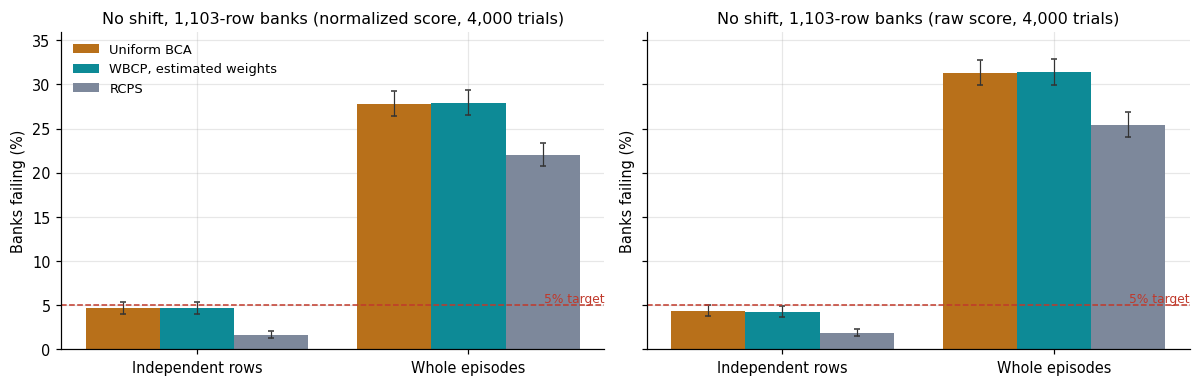

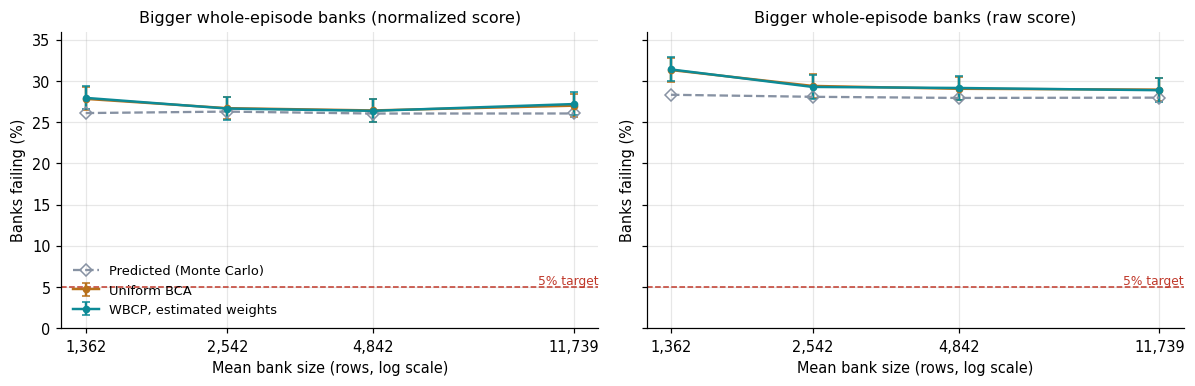

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, s in zip(axes, SCORES):
    grouped(ax, ["Independent rows", "Whole episodes"],
            [(ARMS[k], [A(H + "e0_iid", "policy", 0, 1103, k, s), A(H + "e1_blocks", "policy", 0, 1103, k, s)], COL[k], None) for k in ("BQ-CP", "WBCP", "RCPS")],
            ylim=(0, 36))
    target(ax)
    ax.set_title(f"No shift, 1,103-row banks ({s} score, 4,000 trials)")
axes[0].legend(loc="upper left")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
ns = [1103, 2300, 4600, 11500]
for ax, s in zip(axes, SCORES):
    bs = [B(H + "e1_blocks", "policy", 0, n, s) for n in ns]
    x = [b["cs"] for b in bs]
    line(ax, x, [b["A"]["BQ-CP"] for b in bs], "Uniform BCA", COL["BQ-CP"])
    line(ax, x, [b["A"]["WBCP"] for b in bs], "WBCP, estimated weights", COL["WBCP"])
    ax.plot(x, [pred("hopper", "whole episodes", n, s) for n in ns], ls="--", marker="D", mfc="none", color=COL["pred"], label="Predicted (Monte Carlo)")
    ax.set_xscale("log"); ax.set_xticks(x, [f"{v:,.0f}" for v in x]); ax.minorticks_off()
    ax.set_ylim(0, 36); target(ax)
    ax.set_xlabel("Mean bank size (rows, log scale)"); ax.set_ylabel("Banks failing (%)")
    ax.set_title(f"Bigger whole-episode banks ({s} score)")
axes[0].legend(loc="lower left")
plt.tight_layout(); plt.show()

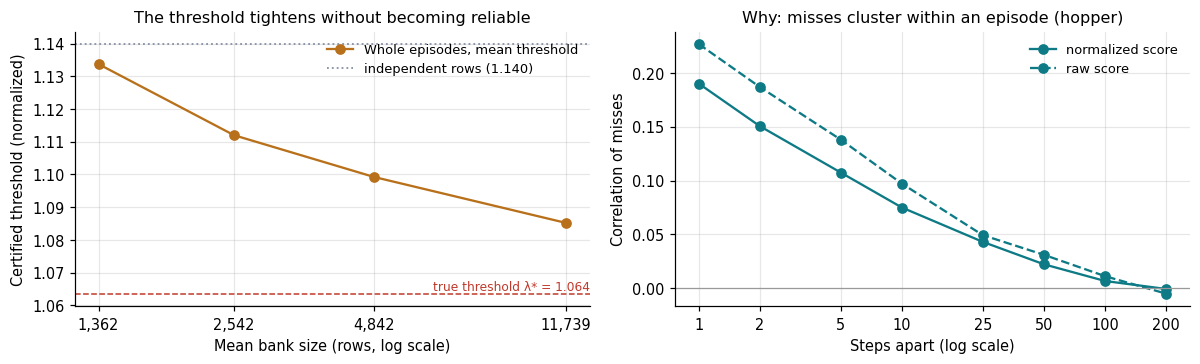

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
bs = [B(H + "e1_blocks", "policy", 0, n) for n in ns]
x = [b["cs"] for b in bs]
ax = axes[0]
ax.plot(x, [b["A"]["BQ-CP"]["th"] for b in bs], marker="o", color=COL["BQ-CP"], label="Whole episodes, mean threshold")
target(ax, bs[0]["L"], f"true threshold λ* = {bs[0]['L']:.3f}")
iid = B(H + "e0_iid", "policy", 0, 1103)
ax.axhline(iid["A"]["BQ-CP"]["th"], color=COL["pred"], ls=":", lw=1.2, label=f"independent rows ({iid['A']['BQ-CP']['th']:.3f})")
ax.set_xscale("log"); ax.set_xticks(x, [f"{v:,.0f}" for v in x]); ax.minorticks_off()
ax.set_xlabel("Mean bank size (rows, log scale)"); ax.set_ylabel("Certified threshold (normalized)")
ax.set_title("The threshold tightens without becoming reliable"); ax.legend(loc="upper right")
ax = axes[1]
for s, ls in zip(SCORES, ("-", "--")):
    lags = D["pred"]["hopper"]["scores"][s]["lags"]
    ks = sorted(int(k) for k in lags)
    ax.plot(ks, [lags[str(k)] for k in ks], marker="o", ls=ls, color=COL["accent"], label=f"{s} score")
ax.axhline(0, color="#999", lw=0.8)
ax.set_xscale("log"); ax.set_xticks(ks, [str(k) for k in ks]); ax.minorticks_off()
ax.set_xlabel("Steps apart (log scale)"); ax.set_ylabel("Correlation of misses")
ax.set_title("Why: misses cluster within an episode (hopper)"); ax.legend()
plt.tight_layout(); plt.show()

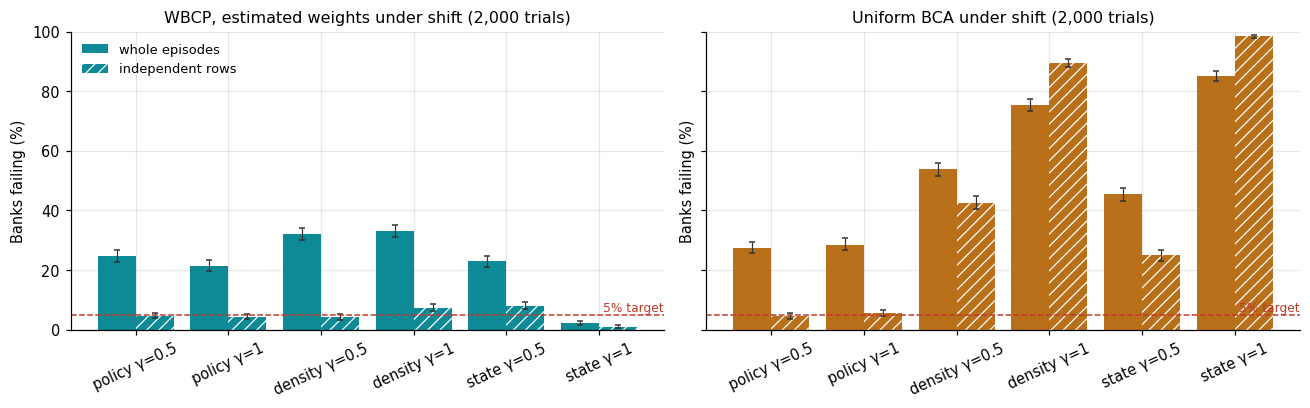

**Whole-episode banks by size, no shift (e1_blocks, 4,000 trials)**

,Score,Target rows,Mean bank,Uniform BCA,WBCP est. w,RCPS,Mean threshold
0,normalized,1103,1362,"27.8% [26.4, 29.2]","28.0% [26.6, 29.4]","22.0% [20.7, 23.3]",1.134
1,normalized,2300,2542,"26.7% [25.3, 28.1]","26.7% [25.3, 28.0]","20.6% [19.3, 21.8]",1.112
2,normalized,4600,4842,"26.4% [25.1, 27.8]","26.4% [25.0, 27.8]","21.0% [19.7, 22.3]",1.099
3,normalized,11500,11739,"27.0% [25.6, 28.4]","27.2% [25.8, 28.6]","20.9% [19.6, 22.2]",1.085
4,raw,1103,1362,"31.3% [29.9, 32.8]","31.4% [30.0, 32.9]","25.5% [24.1, 26.8]",2.356
5,raw,2300,2542,"29.4% [28.0, 30.8]","29.3% [27.9, 30.7]","23.4% [22.0, 24.7]",2.308
6,raw,4600,4842,"29.1% [27.6, 30.5]","29.2% [27.7, 30.6]","23.6% [22.3, 25.0]",2.279
7,raw,11500,11739,"29.0% [27.5, 30.4]","28.9% [27.5, 30.3]","23.5% [22.2, 24.8]",2.247


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
cats = [tl(t, y) for t, y in TILTS]
for ax, (arm, name) in zip(axes, (("WBCP", "WBCP, estimated weights"), ("BQ-CP", "Uniform BCA"))):
    grouped(ax, cats, [("whole episodes", [A("wbcp_bench/blocks", t, y, 1103, arm) for t, y in TILTS], COL[arm], None),
                       ("independent rows", [A("wbcp_bench/main", t, y, 1103, arm) for t, y in TILTS], COL[arm], "///")], ylim=(0, 100))
    target(ax); ax.set_title(f"{name} under shift (2,000 trials)"); ax.tick_params(axis="x", rotation=25)
axes[0].legend(loc="upper left")
plt.tight_layout(); plt.show()

rows = []
for s in SCORES:
    for n in ns:
        b = B(H + "e1_blocks", "policy", 0, n, s)
        rows.append([s, n, round(b["cs"]), fail(b["A"]["BQ-CP"]), fail(b["A"]["WBCP"]), fail(b["A"]["RCPS"]), round(b["A"]["BQ-CP"]["th"], 3)])
display(Markdown("**Whole-episode banks by size, no shift (e1_blocks, 4,000 trials)**"))
display(table(rows, ["Score", "Target rows", "Mean bank", "Uniform BCA", "WBCP est. w", "RCPS", "Mean threshold"]))

## 4. Thinning and spacing (Changes 4, 6)

**Question.** Does taking only K rows from each of many episodes restore validity, and does spacing them apart help?

**Answer.** Yes for small K. K ≤ 10 stays near 5% without shift, the threshold does not widen, and spacing
(one row per K-th of the episode) helps at larger K. The cost is training data: every contributing episode
leaves training (K = 5 withholds about 10-11% of hopper, K = 10 about 5%).

**Verdicts.** Change 4 largely: predictions ran 0.1-1.5 points high. Change 6 mostly: spaced K = 25 fails
6.4% against random 8.0%.

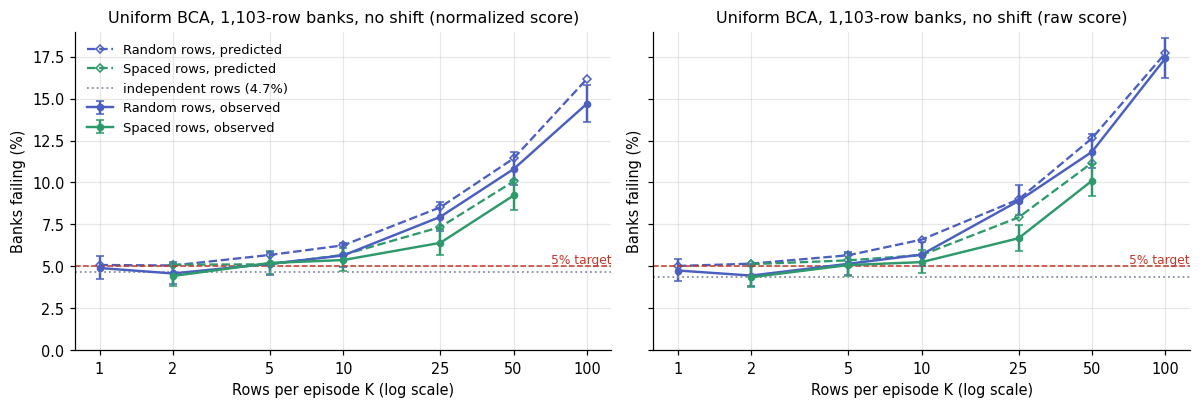

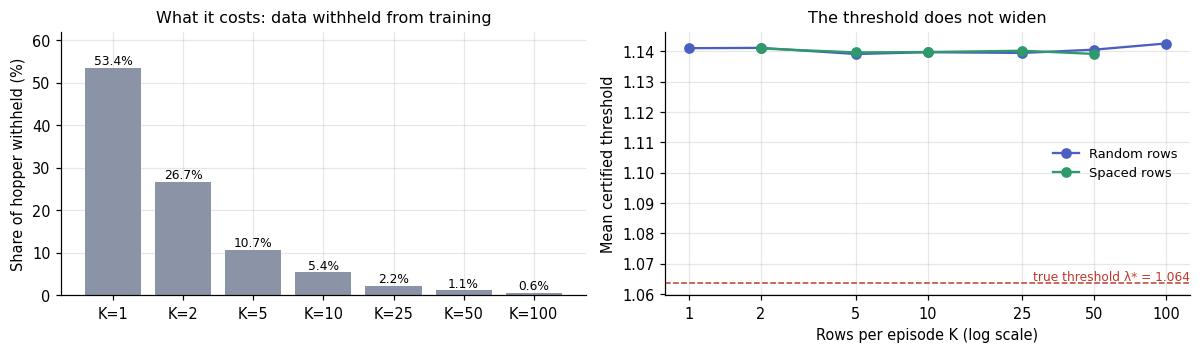

**K sweep, no shift (uniform BCA unless noted; 4,000 trials)**

,K,Score,Random: predicted,Random: uniform BCA,Random: WBCP est. w,Spaced: predicted,Spaced: uniform BCA,Mean threshold
0,1,normalized,5.1%,"4.9% [4.3, 5.6]","5.0% [4.4, 5.7]",–,–,1.141
1,1,raw,5.0%,"4.8% [4.1, 5.5]","4.7% [4.0, 5.3]",–,–,2.377
2,2,normalized,5.1%,"4.6% [3.9, 5.3]","4.8% [4.1, 5.5]",5.1%,"4.4% [3.8, 5.1]",1.141
3,2,raw,5.2%,"4.5% [3.8, 5.1]","4.4% [3.8, 5.1]",5.1%,"4.4% [3.7, 5.0]",2.378
4,5,normalized,5.7%,"5.2% [4.5, 5.9]","5.4% [4.7, 6.1]",5.1%,"5.2% [4.5, 5.9]",1.139
5,5,raw,5.7%,"5.2% [4.5, 5.9]","5.0% [4.3, 5.7]",5.4%,"5.1% [4.4, 5.8]",2.374
6,10,normalized,6.3%,"5.7% [5.0, 6.4]","5.6% [4.9, 6.3]",5.7%,"5.4% [4.7, 6.1]",1.140
7,10,raw,6.6%,"5.7% [5.0, 6.5]","5.8% [5.1, 6.6]",5.7%,"5.3% [4.6, 6.0]",2.375
8,25,normalized,8.5%,"8.0% [7.1, 8.8]","7.9% [7.1, 8.8]",7.3%,"6.4% [5.7, 7.2]",1.139
9,25,raw,9.0%,"8.9% [8.0, 9.8]","9.0% [8.1, 9.9]",7.9%,"6.7% [5.9, 7.5]",2.374


In [5]:
ks, sk = [1, 2, 5, 10, 25, 50, 100], [2, 5, 10, 25, 50]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, s in zip(axes, SCORES):
    line(ax, ks, [A(H + f"e2_k{k}", "policy", 0, 1103, "BQ-CP", s) for k in ks], "Random rows, observed", COL["c3"])
    line(ax, sk, [A(S + f"e6_strat_k{k}", "policy", 0, 1103, "BQ-CP", s) for k in sk], "Spaced rows, observed", COL["c4"])
    ax.plot(ks, [pred("hopper", f"{k} per episode", 1103, s) for k in ks], ls="--", marker="D", ms=3.5, mfc="none", color=COL["c3"], label="Random rows, predicted")
    ax.plot(sk, [pred("hopper-spacing", f"{k} per episode, stratified", 1103, s) for k in sk], ls="--", marker="D", ms=3.5, mfc="none", color=COL["c4"], label="Spaced rows, predicted")
    iid = A(H + "e0_iid", "policy", 0, 1103, "BQ-CP", s)
    ax.axhline(pct(iid), color=COL["pred"], ls=":", lw=1.2, label=f"independent rows ({fmt(iid)}%)")
    target(ax)
    ax.set_xscale("log"); ax.set_xticks(ks, [str(k) for k in ks]); ax.minorticks_off(); ax.set_ylim(0, 19)
    ax.set_xlabel("Rows per episode K (log scale)"); ax.set_ylabel("Banks failing (%)")
    ax.set_title(f"Uniform BCA, 1,103-row banks, no shift ({s} score)")
axes[0].legend(loc="upper left")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.3))
p = D["pred"]["hopper"]
share = [100 * math.ceil(1103 / k) * p["pool"]["size_biased_length"] / p["dataset"]["rows"] for k in ks]
axes[0].bar([f"K={k}" for k in ks], share, color="#8a94a6")
for i, v in enumerate(share):
    axes[0].text(i, v + 0.8, f"{v:.1f}%", ha="center", fontsize=8)
axes[0].set_ylabel("Share of hopper withheld (%)"); axes[0].set_title("What it costs: data withheld from training"); axes[0].set_ylim(0, 62)
lam = B(H + "e0_iid", "policy", 0, 1103)["L"]
axes[1].plot(ks, [A(H + f"e2_k{k}", "policy", 0, 1103, "BQ-CP")["th"] for k in ks], marker="o", color=COL["c3"], label="Random rows")
axes[1].plot(sk, [A(S + f"e6_strat_k{k}", "policy", 0, 1103, "BQ-CP")["th"] for k in sk], marker="o", color=COL["c4"], label="Spaced rows")
target(axes[1], lam, f"true threshold λ* = {lam:.3f}")
axes[1].set_xscale("log"); axes[1].set_xticks(ks, [str(k) for k in ks]); axes[1].minorticks_off()
axes[1].set_xlabel("Rows per episode K (log scale)"); axes[1].set_ylabel("Mean certified threshold"); axes[1].set_title("The threshold does not widen"); axes[1].legend()
plt.tight_layout(); plt.show()

rows = []
for k in ks:
    for s in SCORES:
        r, st = A(H + f"e2_k{k}", "policy", 0, 1103, "BQ-CP", s), A(S + f"e6_strat_k{k}", "policy", 0, 1103, "BQ-CP", s)
        rows.append([k, s, f"{pred('hopper', f'{k} per episode', 1103, s):.1f}%", fail(r), fail(A(H + f"e2_k{k}", "policy", 0, 1103, "WBCP", s)),
                     f"{pred('hopper-spacing', f'{k} per episode, stratified', 1103, s):.1f}%" if k in sk else "–", fail(st), round(r["th"], 3)])
display(Markdown("**K sweep, no shift (uniform BCA unless noted; 4,000 trials)**"))
display(table(rows, ["K", "Score", "Random: predicted", "Random: uniform BCA", "Random: WBCP est. w", "Spaced: predicted", "Spaced: uniform BCA", "Mean threshold"]))

## 5. Distribution shift (Changes 5, 7, 8)

**Question.** Does the WBCP-versus-uniform picture survive thinned banks, and which design holds under shift?

**Answer.**
- Uniform BCA fails 25-98% under density and state shift, while WBCP stays at 4-9%.
- K = 5 holds.
- K = 10 fails 1.3-2.5 points more than K = 5 under the density tilt, spaced or not: it draws from too few
  distinct episodes.

**Verdicts.**
- Change 5 partly: K = 10 missed under the density tilt, and the raw score missed more widely.
- Change 7 yes on the main part: spacing did not fix the density case, as predicted.
- Change 8 yes.

At state γ = 1 WBCP abstains in about a third of banks, which counts as a pass.

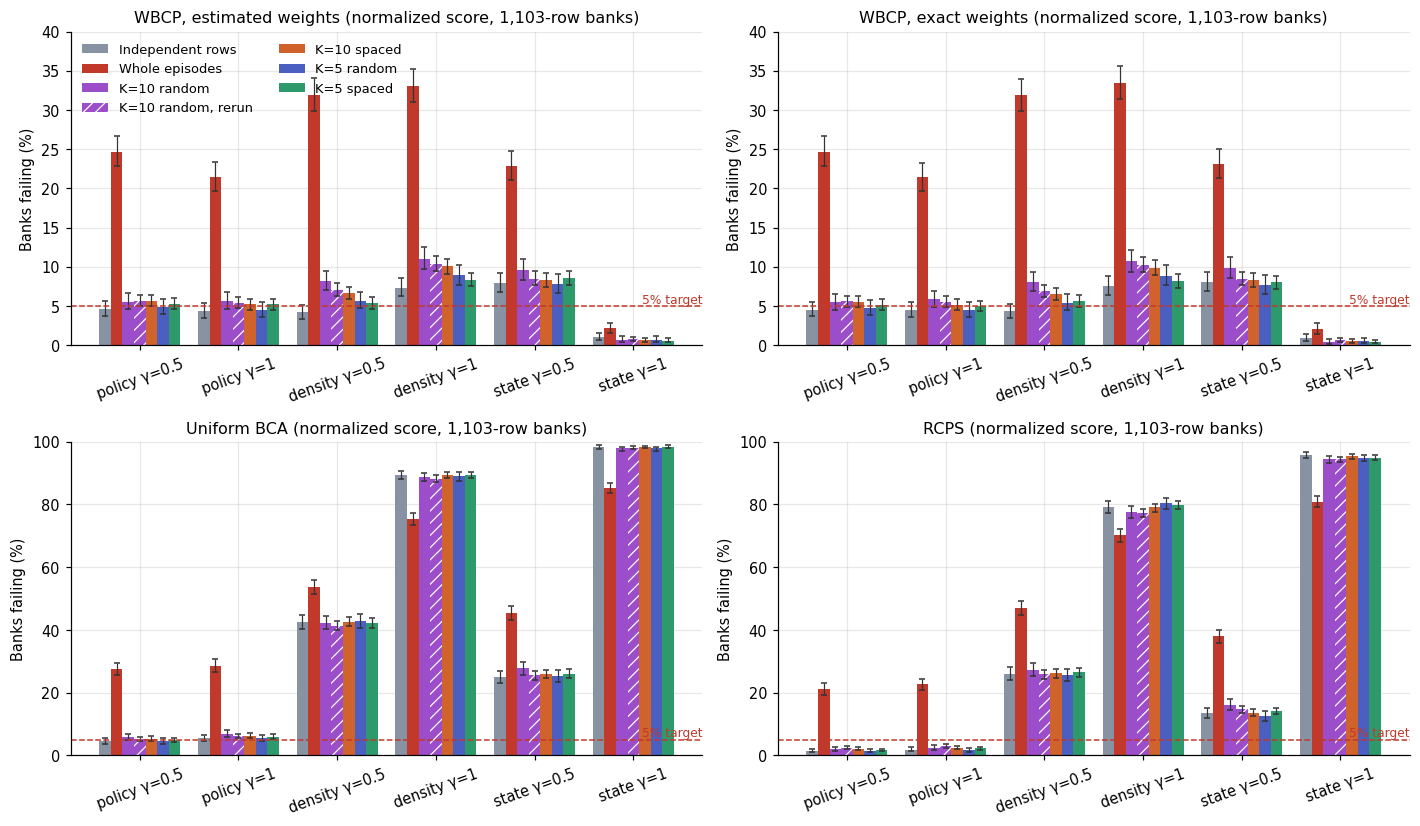

**WBCP (estimated weights) by tilt and design, normalized score**

,Tilt,Independent rows,Whole episodes,K=10 random,"K=10 random, rerun",K=10 spaced,K=5 random,K=5 spaced
0,policy γ=0.5,"4.7% [3.8, 5.7]","24.7% [22.8, 26.7]","5.6% [4.6, 6.6]","5.7% [5.0, 6.5]","5.7% [5.0, 6.4]","4.9% [4.0, 5.9]","5.3% [4.6, 6.0]"
1,policy γ=1,"4.4% [3.5, 5.3]","21.5% [19.7, 23.4]","5.7% [4.7, 6.8]","5.4% [4.7, 6.1]","5.2% [4.5, 5.9]","4.5% [3.6, 5.5]","5.2% [4.5, 5.9]"
2,density γ=0.5,"4.2% [3.4, 5.2]","32.0% [29.9, 34.0]","8.2% [7.0, 9.5]","7.1% [6.3, 7.9]","6.7% [5.9, 7.5]","5.7% [4.7, 6.8]","5.4% [4.7, 6.1]"
3,density γ=1,"7.4% [6.2, 8.6]","33.1% [31.0, 35.2]","11.1% [9.7, 12.5]","10.4% [9.5, 11.4]","10.1% [9.1, 11.0]","9.0% [7.7, 10.3]","8.4% [7.5, 9.3]"
4,state γ=0.5,"8.0% [6.8, 9.2]","22.9% [21.1, 24.8]","9.6% [8.3, 11.0]","8.5% [7.7, 9.4]","8.3% [7.4, 9.2]","7.8% [6.7, 9.1]","8.5% [7.7, 9.4]"
5,state γ=1,"1.0% [0.6, 1.5]","2.2% [1.6, 2.9]","0.7% [0.4, 1.2]","0.8% [0.5, 1.1]","0.7% [0.4, 1.0]","0.7% [0.4, 1.2]","0.6% [0.4, 0.9]"


**WBCP (estimated weights) by tilt and design, raw score**

,Tilt,Independent rows,Whole episodes,K=10 random,"K=10 random, rerun",K=10 spaced,K=5 random,K=5 spaced
0,policy γ=0.5,"4.9% [4.0, 5.9]","28.2% [26.2, 30.2]","5.5% [4.5, 6.5]","5.7% [5.0, 6.5]","5.7% [5.0, 6.4]","4.4% [3.5, 5.3]","5.5% [4.8, 6.2]"
1,policy γ=1,"4.2% [3.4, 5.2]","24.8% [22.9, 26.8]","5.8% [4.8, 6.9]","5.9% [5.1, 6.6]","4.9% [4.2, 5.6]","5.0% [4.0, 6.0]","5.7% [5.0, 6.5]"
2,density γ=0.5,"4.5% [3.6, 5.4]","34.9% [32.8, 37.0]","7.7% [6.5, 8.9]","7.8% [6.9, 8.6]","7.5% [6.7, 8.3]","5.6% [4.6, 6.6]","5.6% [4.9, 6.4]"
3,density γ=1,"7.9% [6.8, 9.2]","34.3% [32.2, 36.4]","11.1% [9.7, 12.5]","9.9% [9.0, 10.9]","10.4% [9.5, 11.4]","9.5% [8.3, 10.9]","8.4% [7.6, 9.3]"
4,state γ=0.5,"8.5% [7.3, 9.8]","26.4% [24.5, 28.4]","10.7% [9.4, 12.1]","8.1% [7.2, 8.9]","8.9% [8.0, 9.8]","8.0% [6.8, 9.2]","8.3% [7.4, 9.2]"
5,state γ=1,"0.9% [0.5, 1.4]","3.2% [2.4, 4.0]","1.1% [0.7, 1.6]","0.6% [0.4, 0.9]","0.9% [0.6, 1.2]","0.9% [0.5, 1.4]","0.8% [0.5, 1.1]"


In [6]:
designs = [("Independent rows", "wbcp_bench/main", COL["pred"], None), ("Whole episodes", "wbcp_bench/blocks", COL["target"], None),
           ("K=10 random", H + "e3_k10", COL["c5"], None), ("K=10 random, rerun", S + "e7_random_k10", COL["c5"], "///"),
           ("K=10 spaced", S + "e7_stratified_k10", COL["c6"], None), ("K=5 random", H + "e3_k5", COL["c3"], None), ("K=5 spaced", S + "e8_stratified_k5", COL["c4"], None)]
cats = [tl(t, y) for t, y in TILTS]
fig, axes = plt.subplots(2, 2, figsize=(13, 7.6))
for ax, arm in zip(axes.ravel(), ("WBCP", "WBCP (oracle w)", "BQ-CP", "RCPS")):
    grouped(ax, cats, [(name, [A(e, t, y, 1103, arm) for t, y in TILTS], color, hatch) for name, e, color, hatch in designs],
            ylim=(0, 100 if arm in ("BQ-CP", "RCPS") else 40))
    target(ax); ax.set_title(f"{ARMS[arm]} (normalized score, 1,103-row banks)"); ax.tick_params(axis="x", rotation=20)
axes[0, 0].legend(loc="upper left", ncol=2)
plt.tight_layout(); plt.show()

for s in SCORES:
    rows = [[tl(t, y)] + [fail(A(e, t, y, 1103, "WBCP", s)) for _, e, _, _ in designs] for t, y in TILTS]
    display(Markdown(f"**WBCP (estimated weights) by tilt and design, {s} score**"))
    display(table(rows, ["Tilt"] + [d[0] for d in designs]))

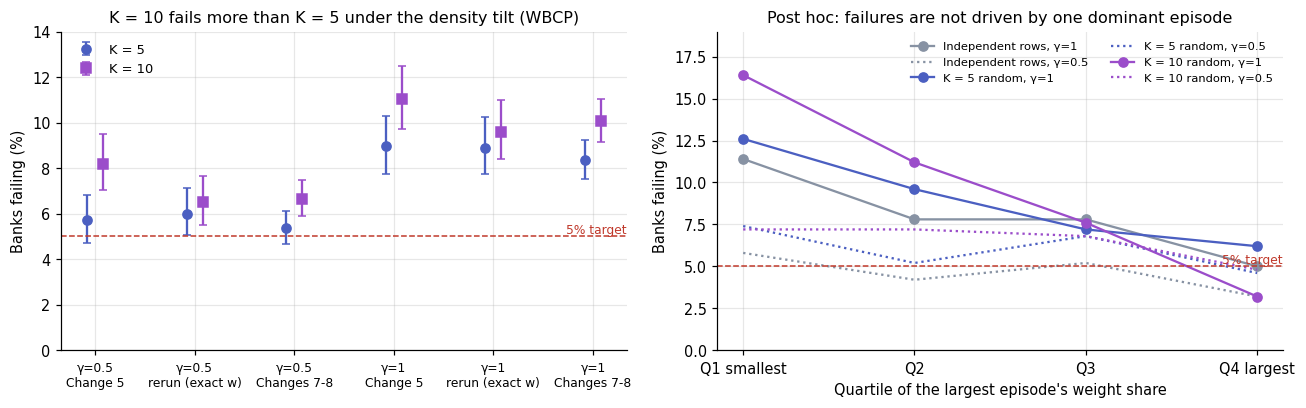

**Post hoc: design effect recomputed under each tilt (exact weights; K = 5 entries are noisy)**

,Tilt,D at K=5,D at K=10,iid failure,K=10 predicted,K=10 observed,ρ of tilt feature,ρ of weighted misses
0,policy γ=0.5,1.079,1.136,4.55%,5.64%,5.50%,0.0145,0.0088
1,policy γ=1,1.083,1.123,4.45%,5.43%,5.85%,0.0145,0.0054
2,density γ=0.5,1.101,1.205,4.30%,5.89%,8.10%,0.0500,0.0324
3,density γ=1,1.032,1.188,7.55%,9.39%,10.70%,0.0500,0.0430
4,state γ=0.5,1.110,1.144,8.05%,9.50%,9.80%,0.0131,0.0100
5,state γ=1,0.953,0.962,0.95%,0.84%,0.45%,0.0131,0.0037


In [7]:
def pseudo(p, n):
    z = 1.96; d = 1 + z * z / n; c = (p + z * z / (2 * n)) / d; h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return {"f": round(p * n), "T": n, "lo": c - h, "hi": c + h}

cats, k5, k10 = [], [], []
for g in (0.5, 1.0):
    key = "1.0" if g == 1 else "0.5"
    cats += [f"γ={g:g}\nChange 5", f"γ={g:g}\nrerun (exact w)", f"γ={g:g}\nChanges 7-8"]
    k5 += [A(H + "e3_k5", "density", g, 1103, "WBCP"), pseudo(D["dominant"][f"gamma={key} 5"]["fail"], 2000), A(S + "e8_stratified_k5", "density", g, 1103, "WBCP")]
    k10 += [A(H + "e3_k10", "density", g, 1103, "WBCP"), pseudo(D["dominant"][f"gamma={key} 10"]["fail"], 2000), A(S + "e7_stratified_k10", "density", g, 1103, "WBCP")]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
x = np.arange(len(cats))
axes[0].errorbar(x - 0.08, [pct(a) for a in k5], yerr=yerr(k5), fmt="o", color=COL["c3"], capsize=2.5, label="K = 5")
axes[0].errorbar(x + 0.08, [pct(a) for a in k10], yerr=yerr(k10), fmt="s", color=COL["c5"], capsize=2.5, label="K = 10")
axes[0].set_xticks(x, cats, fontsize=8); axes[0].set_ylim(0, 14); target(axes[0]); axes[0].legend(loc="upper left")
axes[0].set_ylabel("Banks failing (%)"); axes[0].set_title("K = 10 fails more than K = 5 under the density tilt (WBCP)")
q = ["Q1 smallest", "Q2", "Q3", "Q4 largest"]
for key, name, color in (("iid", "Independent rows", COL["pred"]), ("5", "K = 5 random", COL["c3"]), ("10", "K = 10 random", COL["c5"])):
    axes[1].plot(q, [100 * v for v in D["dominant"][f"gamma=1.0 {key}"]["fail_by_share_quartile"]], marker="o", color=color, label=f"{name}, γ=1")
    axes[1].plot(q, [100 * v for v in D["dominant"][f"gamma=0.5 {key}"]["fail_by_share_quartile"]], ls=":", color=color, label=f"{name}, γ=0.5")
target(axes[1]); axes[1].set_ylim(0, 19); axes[1].legend(fontsize=7.5, ncol=2)
axes[1].set_xlabel("Quartile of the largest episode's weight share"); axes[1].set_ylabel("Banks failing (%)")
axes[1].set_title("Post hoc: failures are not driven by one dominant episode")
plt.tight_layout(); plt.show()

rows = [[k.replace(" gamma=", " γ=").replace(".0", ""), round(v["D_K5"], 3), round(v["D_K10"], 3), f"{100 * v['iid_oracle_fail']:.2f}%",
         f"{100 * v['predicted_K10']:.2f}%", f"{100 * v['observed_K10']:.2f}%", round(v["rho_feature"], 4), round(v["rho_weighted_miss"], 4)] for k, v in D["tilted_hopper"].items()]
display(Markdown("**Post hoc: design effect recomputed under each tilt (exact weights; K = 5 entries are noisy)**"))
display(table(rows, ["Tilt", "D at K=5", "D at K=10", "iid failure", "K=10 predicted", "K=10 observed", "ρ of tilt feature", "ρ of weighted misses"]))

## 6. BCA's implemented bank (Change 9)

**Question.** Does BCA's own implementation of the thinned bank behave like the validated design, and what K does
each config get?

**Answer.**
- On hopper, BCA's sampler (distinct episodes chosen in proportion to length, K spaced rows each) fails 5.0%
  without shift and meets every shift range.
- Under the rule "K = 5, raised until it fits the withholding cap", most TD3+BC / ReBRAC / CQL banks stay inside
  the validated range (K ≤ 10 from at least 100 episodes). Most IQL banks do not.
- IQL on hopper (K = 18, 8,192 rows) lies between 5.0% and 6.7%.

**Verdict.** Mostly: the four expectations came out yes, mostly, yes, yes.

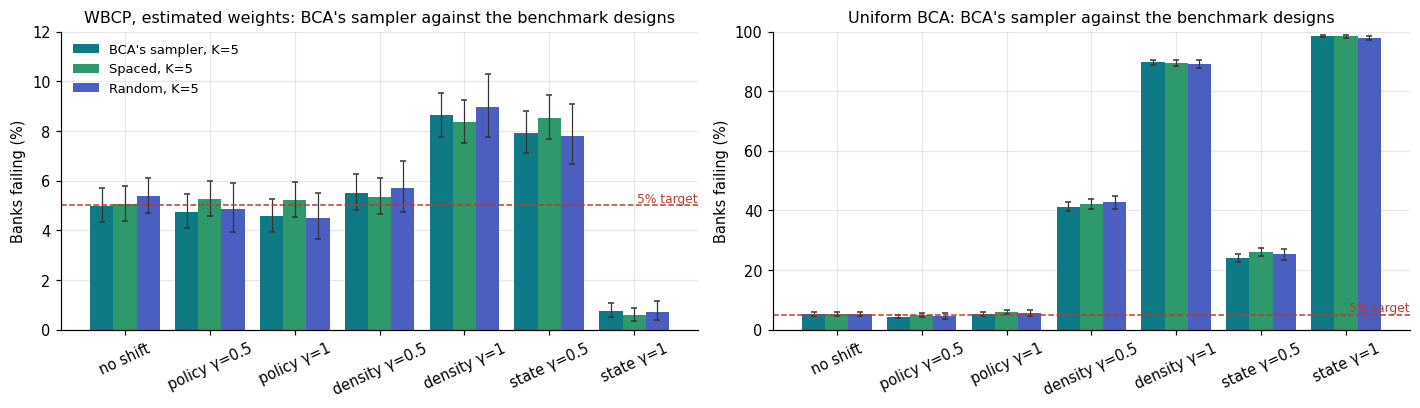

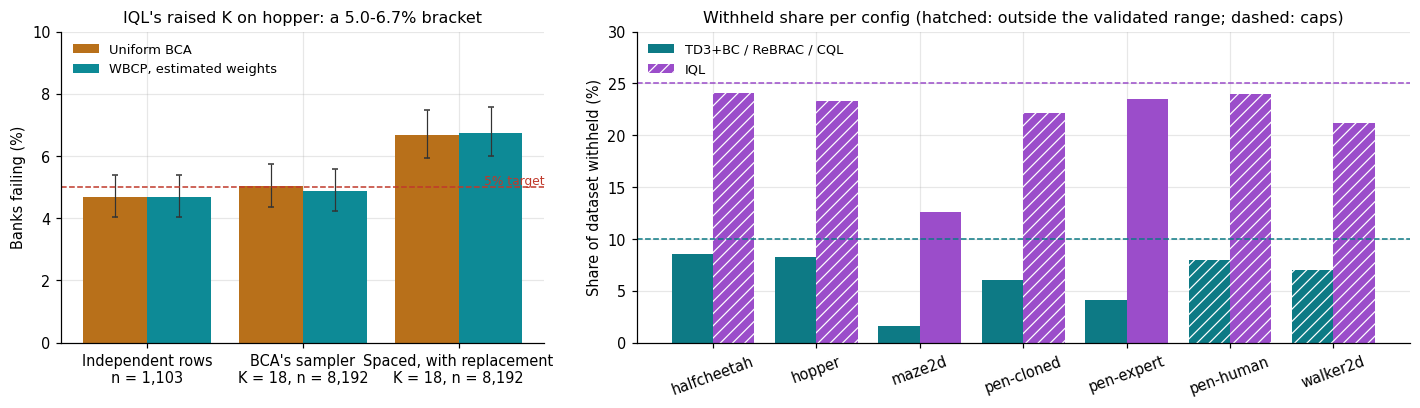

**Rows per episode by host and dataset (rule: smallest K ≥ 5 that fits the cap for 1,000 simulated seeds)**

,Dataset,Hosts,Bank target,Cap,K,Episodes,Bank rows,Withheld,Validated range
0,halfcheetah,TD3+BC / ReBRAC / CQL,1024,10%,6,171,1026,8.6%,inside
1,halfcheetah,IQL,8192,25%,17,482,8194,24.1%,outside
2,hopper,TD3+BC / ReBRAC / CQL,1024,10%,6,171,1026,8.3%,inside
3,hopper,IQL,8192,25%,17,482,8194,23.3%,outside
4,maze2d,TD3+BC / ReBRAC / CQL,1024,10%,5,205,1025,1.6%,inside
5,maze2d,IQL,8192,25%,5,1639,8195,12.6%,inside
6,pen-cloned,TD3+BC / ReBRAC / CQL,1024,10%,5,205,1025,6.1%,inside
7,pen-cloned,IQL,8192,25%,11,745,8195,22.2%,outside
8,pen-expert,TD3+BC / ReBRAC / CQL,1024,10%,5,205,1025,4.1%,inside
9,pen-expert,IQL,8192,25%,7,1171,8197,23.5%,inside


In [8]:
cats = ["no shift"] + [tl(t, y) for t, y in TILTS]
row = lambda e0, e1, arm: [A(e0, "policy", 0, 1103, arm)] + [A(e1, t, y, 1103, arm) for t, y in TILTS]
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for ax, arm in zip(axes, ("WBCP", "BQ-CP")):
    grouped(ax, cats, [("BCA's sampler, K=5", row(R + "r1_resv_k5", R + "r2_resv_k5_shift", arm), COL["accent"], None),
                       ("Spaced, K=5", row(S + "e6_strat_k5", S + "e8_stratified_k5", arm), COL["c4"], None),
                       ("Random, K=5", row(H + "e2_k5", H + "e3_k5", arm), COL["c3"], None)], ylim=(0, 12 if arm == "WBCP" else 100))
    target(ax); ax.set_title(f"{ARMS[arm]}: BCA's sampler against the benchmark designs"); ax.tick_params(axis="x", rotation=25)
axes[0].legend(loc="upper left")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), gridspec_kw={"width_ratios": [1, 1.6]})
src = [(H + "e0_iid", 1103), (R + "r3_resv_k18_n8192", 8192), (R + "r4_strat_k18_n8192", 8192)]
grouped(axes[0], ["Independent rows\nn = 1,103", "BCA's sampler\nK = 18, n = 8,192", "Spaced, with replacement\nK = 18, n = 8,192"],
        [(ARMS[k], [A(e, "policy", 0, n, k) for e, n in src], COL[k], None) for k in ("BQ-CP", "WBCP")], ylim=(0, 10))
target(axes[0]); axes[0].set_title("IQL's raised K on hopper: a 5.0-6.7% bracket"); axes[0].legend(loc="upper left")
DS = ["halfcheetah", "hopper", "maze2d", "pen-cloned", "pen-expert", "pen-human", "walker2d"]
x = np.arange(len(DS))
for i, (host, name, color) in enumerate((("td3_bc", "TD3+BC / ReBRAC / CQL", COL["accent"]), ("iql", "IQL", COL["c5"]))):
    rows_ = [D["configs"][host][d] for d in DS]
    for j, r in enumerate(rows_):
        axes[1].bar(x[j] - 0.2 + 0.4 * i, 100 * r["withheld_share_at_seed"], 0.4, color=color, hatch=None if r["dependence_validated"] else "///",
                    edgecolor="white", linewidth=0, label=name if j == 0 else None)
axes[1].axhline(10, color=COL["accent"], ls="--", lw=1); axes[1].axhline(25, color=COL["c5"], ls="--", lw=1)
axes[1].set_xticks(x, DS, rotation=20); axes[1].set_ylabel("Share of dataset withheld (%)"); axes[1].set_ylim(0, 30)
axes[1].set_title("Withheld share per config (hatched: outside the validated range; dashed: caps)"); axes[1].legend(loc="upper left")
plt.tight_layout(); plt.show()

rows = [[d, name, r["target"], f"{100 * r['cap']:.0f}%", r["rows_per_episode"], r["episodes"], r["calibration_rows"], f"{100 * r['withheld_share_at_seed']:.1f}%",
         "inside" if r["dependence_validated"] else "outside"] for d in DS for host, name in (("td3_bc", "TD3+BC / ReBRAC / CQL"), ("iql", "IQL")) for r in [D["configs"][host][d]]]
display(Markdown("**Rows per episode by host and dataset (rule: smallest K ≥ 5 that fits the cap for 1,000 simulated seeds)**"))
display(table(rows, ["Dataset", "Hosts", "Bank target", "Cap", "K", "Episodes", "Bank rows", "Withheld", "Validated range"]))

## 7. Other datasets (Change 10)

**Question.** Does hopper's answer (K = 5) carry over to walker2d-medium-replay and pen-cloned?

**Answer.**
- No. ρ is 0.120 on walker2d and 0.108 on pen-cloned, about 7× hopper's.
- K = 5 fails 6-8%, and the configured walker2d banks fail 18-30%.
- On walker2d the correlation never fades within an episode, so spacing cannot help.
- Estimated weights also hurt WBCP there even without shift, unless the weight model gets far more data: 10×
  more brought it from 14.9% to 5.7%.

**Verdicts.**
- Stage A mostly: ρ landed just above the pre-registered 0.02-0.10.
- Stage B without shift mostly.
- Stage B under shift no on walker2d, mixed on pen-cloned. Failure fell where it was expected to rise; a
  post-hoc explanation is in the last figure.
- Stage D yes.

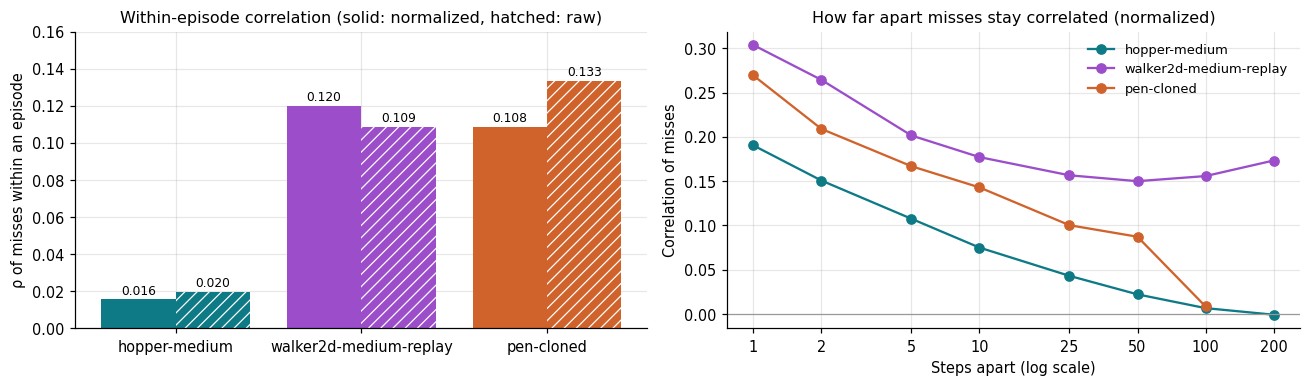

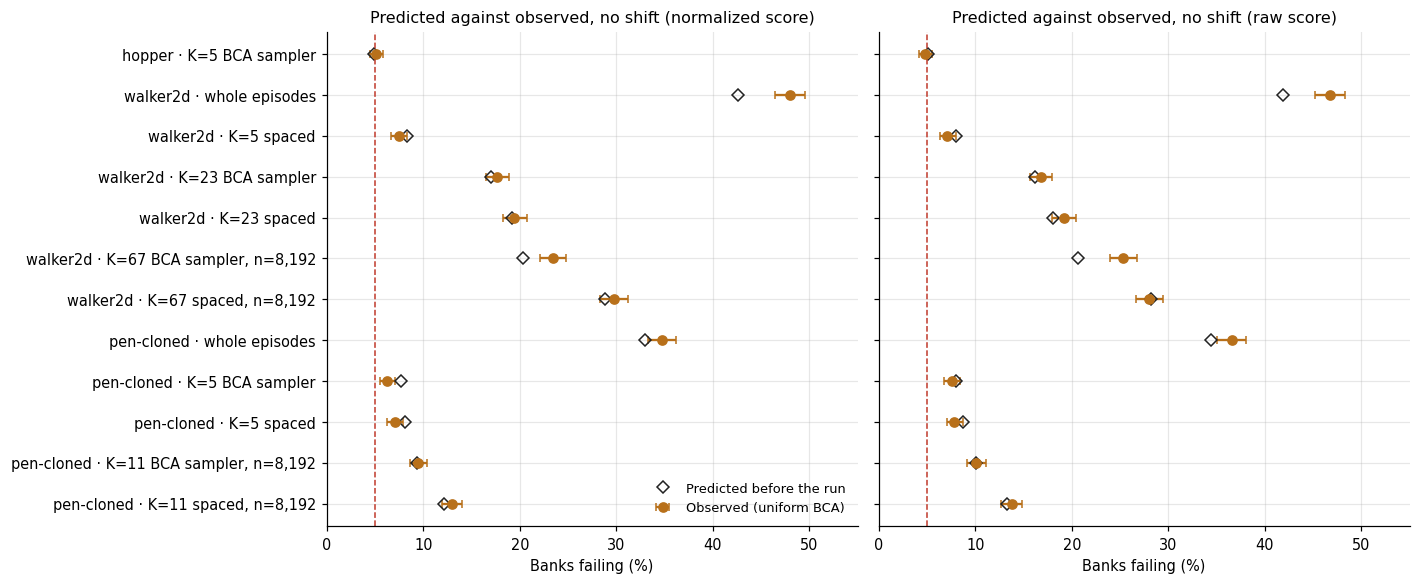

**Designs without shift (4,000 trials)**

,Design,Score,Predicted,Uniform BCA,WBCP exact w,WBCP est. w
0,hopper · K=5 BCA sampler,normalized,4.9%,"5.1% [4.4, 5.8]","5.2% [4.6, 6.0]","5.0% [4.3, 5.7]"
1,hopper · K=5 BCA sampler,raw,5.1%,"4.8% [4.2, 5.5]","4.9% [4.3, 5.6]","5.0% [4.3, 5.7]"
2,walker2d · whole episodes,normalized,42.6%,"48.0% [46.4, 49.6]","47.9% [46.3, 49.5]","47.7% [46.1, 49.3]"
3,walker2d · whole episodes,raw,41.9%,"46.8% [45.2, 48.3]","47.1% [45.5, 48.7]","46.8% [45.2, 48.3]"
4,walker2d · K=5 spaced,normalized,8.4%,"7.5% [6.7, 8.4]","7.7% [6.9, 8.6]","9.1% [8.2, 10.0]"
5,walker2d · K=5 spaced,raw,8.0%,"7.1% [6.3, 8.0]","7.2% [6.4, 8.0]","8.6% [7.7, 9.5]"
6,walker2d · K=23 BCA sampler,normalized,17.0%,"17.7% [16.5, 18.9]","17.7% [16.6, 18.9]","18.4% [17.2, 19.7]"
7,walker2d · K=23 BCA sampler,raw,16.2%,"16.8% [15.7, 18.0]","16.8% [15.6, 17.9]","17.6% [16.4, 18.8]"
8,walker2d · K=23 spaced,normalized,19.2%,"19.5% [18.2, 20.7]","19.5% [18.3, 20.7]","20.5% [19.3, 21.8]"
9,walker2d · K=23 spaced,raw,18.0%,"19.2% [18.0, 20.4]","19.1% [17.9, 20.4]","19.3% [18.1, 20.6]"


In [9]:
DSETS = [("hopper", "hopper-medium", COL["accent"]), ("walker2d-n1024", "walker2d-medium-replay", COL["c5"]), ("pen-n1024", "pen-cloned", COL["c6"])]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
x = np.arange(len(DSETS))
for i, s in enumerate(SCORES):
    vals = [D["pred"][src]["scores"][s]["rho"] for src, _, _ in DSETS]
    axes[0].bar(x - 0.2 + 0.4 * i, vals, 0.4, color=[c for _, _, c in DSETS], hatch=None if i == 0 else "///", edgecolor="white", linewidth=0, label=f"{s} score")
    for j, v in enumerate(vals):
        axes[0].text(x[j] - 0.2 + 0.4 * i, v + 0.003, f"{v:.3f}", ha="center", fontsize=8)
axes[0].set_xticks(x, [name for _, name, _ in DSETS]); axes[0].set_ylabel("ρ of misses within an episode"); axes[0].set_ylim(0, 0.16)
axes[0].set_title("Within-episode correlation (solid: normalized, hatched: raw)")
for src, name, color in DSETS:
    lags = D["pred"][src]["scores"]["normalized"]["lags"]
    kk = sorted(int(k) for k in lags)
    axes[1].plot(kk, [lags[str(k)] for k in kk], marker="o", color=color, label=name)
axes[1].axhline(0, color="#999", lw=0.8); axes[1].set_xscale("log"); axes[1].set_xticks(kk, [str(k) for k in kk]); axes[1].minorticks_off()
axes[1].set_xlabel("Steps apart (log scale)"); axes[1].set_ylabel("Correlation of misses"); axes[1].set_title("How far apart misses stay correlated (normalized)"); axes[1].legend()
plt.tight_layout(); plt.show()

DESIGNS = [("hopper · K=5 BCA sampler", R + "r1_resv_k5", 1103, "hopper-k5", "5 per episode, BCA reservation"),
           ("walker2d · whole episodes", O + "w_blocks_n1024", 1024, "walker2d-n1024", "whole episodes"),
           ("walker2d · K=5 spaced", O + "w_strat5_n1024", 1024, "walker2d-n1024", "5 per episode, stratified"),
           ("walker2d · K=23 BCA sampler", O + "w_resv23_n1024", 1024, "walker2d-n1024", "23 per episode, BCA reservation"),
           ("walker2d · K=23 spaced", O + "w_strat23_n1024", 1024, "walker2d-n1024", "23 per episode, stratified"),
           ("walker2d · K=67 BCA sampler, n=8,192", O + "w_resv67_n8192", 8192, "walker2d-n8192", "67 per episode, BCA reservation"),
           ("walker2d · K=67 spaced, n=8,192", O + "w_strat67_n8192", 8192, "walker2d-n8192", "67 per episode, stratified"),
           ("pen-cloned · whole episodes", O + "p_blocks_n1024", 1024, "pen-n1024", "whole episodes"),
           ("pen-cloned · K=5 BCA sampler", O + "p_resv5_n1024", 1024, "pen-n1024", "5 per episode, BCA reservation"),
           ("pen-cloned · K=5 spaced", O + "p_strat5_n1024", 1024, "pen-n1024", "5 per episode, stratified"),
           ("pen-cloned · K=11 BCA sampler, n=8,192", O + "p_resv11_n8192", 8192, "pen-n8192", "11 per episode, BCA reservation"),
           ("pen-cloned · K=11 spaced, n=8,192", O + "p_strat11_n8192", 8192, "pen-n8192", "11 per episode, stratified")]
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), sharey=True)
y = np.arange(len(DESIGNS))[::-1]
for ax, s in zip(axes, SCORES):
    arms = [A(e, "policy", 0, n, "BQ-CP", s) for _, e, n, _, _ in DESIGNS]
    ax.errorbar([pct(a) for a in arms], y, xerr=yerr(arms), fmt="o", color=COL["BQ-CP"], capsize=2.5, label="Observed (uniform BCA)")
    ax.plot([pred(src, dz, n, s) for _, _, n, src, dz in DESIGNS], y, "D", mfc="none", color="#222", label="Predicted before the run")
    ax.axvline(5, color=COL["target"], ls="--", lw=1)
    ax.set_yticks(y, [d[0] for d in DESIGNS]); ax.set_xlim(0, 55); ax.set_xlabel("Banks failing (%)"); ax.set_title(f"Predicted against observed, no shift ({s} score)")
axes[0].legend(loc="lower right")
plt.tight_layout(); plt.show()

rows = [[label, s, f"{pred(src, dz, n, s):.1f}%", fail(A(e, "policy", 0, n, "BQ-CP", s)), fail(A(e, "policy", 0, n, "WBCP (oracle w)", s)), fail(A(e, "policy", 0, n, "WBCP", s))]
        for label, e, n, src, dz in DESIGNS for s in SCORES]
display(Markdown("**Designs without shift (4,000 trials)**"))
display(table(rows, ["Design", "Score", "Predicted", "Uniform BCA", "WBCP exact w", "WBCP est. w"]))

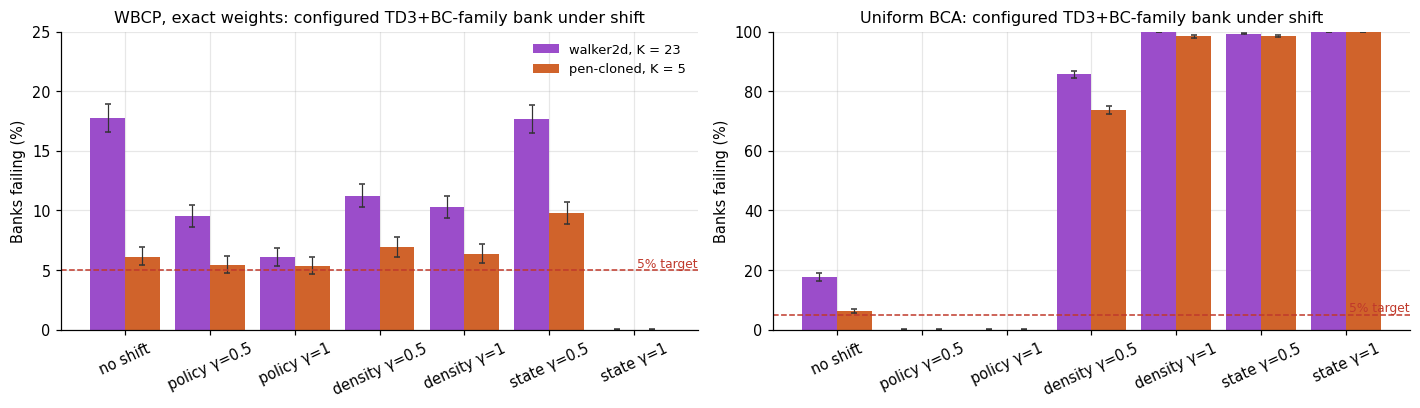

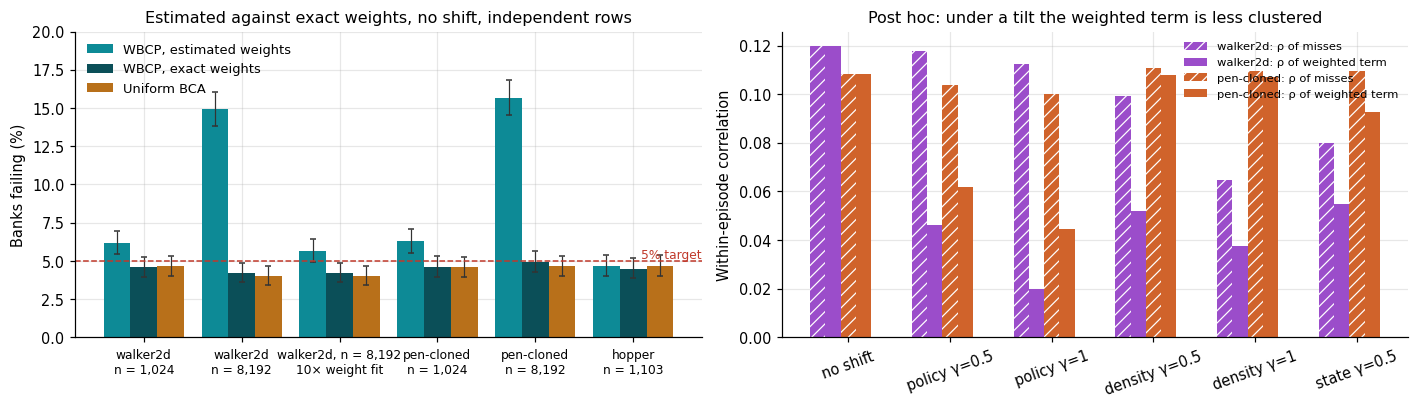

**Configured bank under shift (normalized score, 4,000 trials)**

,Bank,Tilt,WBCP exact w,WBCP est. w,Uniform BCA,"Mean excess | fail (points, exact w)"
0,walker2d K=23,no shift,"17.7% [16.6, 18.9]","18.4% [17.2, 19.7]","17.7% [16.5, 18.9]",0.85
1,walker2d K=23,policy γ=0.5,"9.5% [8.6, 10.5]","10.0% [9.1, 10.9]","0.0% [0.0, 0.1]",0.48
2,walker2d K=23,policy γ=1,"6.1% [5.4, 6.9]","6.5% [5.7, 7.3]","0.0% [0.0, 0.1]",0.49
3,walker2d K=23,density γ=0.5,"11.2% [10.3, 12.2]","12.5% [11.5, 13.6]","85.7% [84.6, 86.8]",0.86
4,walker2d K=23,density γ=1,"10.3% [9.3, 11.2]","11.0% [10.0, 12.0]","100.0% [99.9, 100.0]",1.02
5,walker2d K=23,state γ=0.5,"17.7% [16.5, 18.9]","18.1% [16.9, 19.3]","99.3% [99.0, 99.6]",1.34
6,walker2d K=23,state γ=1,"0.0% [0.0, 0.1]","0.0% [0.0, 0.1]","100.0% [99.9, 100.0]",–
7,pen-cloned K=5,no shift,"6.1% [5.4, 6.9]","7.7% [6.9, 8.6]","6.3% [5.5, 7.1]",0.54
8,pen-cloned K=5,policy γ=0.5,"5.4% [4.7, 6.1]","6.0% [5.3, 6.8]","0.0% [0.0, 0.1]",0.43
9,pen-cloned K=5,policy γ=1,"5.3% [4.6, 6.1]","5.7% [5.0, 6.5]","0.0% [0.0, 0.1]",0.51


**Post hoc: tilted correlation and the failure it implies**

,Dataset,Tilt,γ,λ*,ρ of misses,ρ of weighted term,Design effect,Implied failure
0,walker2d-medium-replay,policy,0.0,1.261,0.1198,0.1198,3.64,19.4%
1,walker2d-medium-replay,policy,0.5,1.061,0.1177,0.0461,2.01,12.3%
2,walker2d-medium-replay,policy,1.0,0.968,0.1125,0.0199,1.44,8.5%
3,walker2d-medium-replay,density,0.5,1.481,0.0992,0.0521,2.15,13.1%
4,walker2d-medium-replay,density,1.0,1.741,0.0646,0.0375,1.82,11.2%
5,walker2d-medium-replay,state,0.5,1.632,0.0798,0.0550,2.21,13.4%
6,pen-cloned,policy,0.0,1.113,0.1084,0.1084,1.43,8.5%
7,pen-cloned,policy,0.5,0.983,0.1038,0.0619,1.25,7.0%
8,pen-cloned,policy,1.0,0.921,0.0999,0.0446,1.18,6.5%
9,pen-cloned,density,0.5,1.224,0.1106,0.1077,1.43,8.5%


In [10]:
cats = ["no shift"] + [tl(t, y) for t, y in TILTS]
row = lambda e0, e1, arm: [A(e0, "policy", 0, 1024, arm)] + [A(e1, t, y, 1024, arm) for t, y in TILTS]
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for ax, arm in zip(axes, ("WBCP (oracle w)", "BQ-CP")):
    grouped(ax, cats, [("walker2d, K = 23", row(O + "w_resv23_n1024", O + "w_resv23_shift", arm), COL["c5"], None),
                       ("pen-cloned, K = 5", row(O + "p_resv5_n1024", O + "p_resv5_shift", arm), COL["c6"], None)], ylim=(0, 25 if arm != "BQ-CP" else 100))
    target(ax); ax.set_title(f"{ARMS[arm]}: configured TD3+BC-family bank under shift"); ax.tick_params(axis="x", rotation=25)
axes[0].legend(loc="upper right")
plt.tight_layout(); plt.show()

src = [("walker2d\nn = 1,024", O + "w_iid_n1024", 1024), ("walker2d\nn = 8,192", O + "w_iid_n8192", 8192), ("walker2d, n = 8,192\n10× weight fit", O + "d_w_iid_n8192_fit10000", 8192),
       ("pen-cloned\nn = 1,024", O + "p_iid_n1024", 1024), ("pen-cloned\nn = 8,192", O + "p_iid_n8192", 8192), ("hopper\nn = 1,103", H + "e0_iid", 1103)]
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
grouped(axes[0], [s_[0] for s_ in src], [(ARMS[k], [A(e, "policy", 0, n, k) for _, e, n in src], COL[k], None) for k in ("WBCP", "WBCP (oracle w)", "BQ-CP")], ylim=(0, 20))
target(axes[0]); axes[0].set_title("Estimated against exact weights, no shift, independent rows"); axes[0].legend(loc="upper left"); axes[0].tick_params(axis="x", labelsize=8)
x = np.arange(6); labels = None
for i, (key, name, color) in enumerate((("walker2d-medium-replay", "walker2d", COL["c5"]), ("pen-cloned", "pen-cloned", COL["c6"]))):
    rows_ = D["tilted_rho"][key]
    labels = ["no shift" if r["gamma"] == 0 else tl(r["tilt"], r["gamma"]) for r in rows_]
    axes[1].bar(x - 0.3 + 0.3 * i, [r["rho_miss"] for r in rows_], 0.15, color=color, hatch="///", edgecolor="white", linewidth=0, label=f"{name}: ρ of misses")
    axes[1].bar(x - 0.15 + 0.3 * i, [r["rho_weighted"] for r in rows_], 0.15, color=color, label=f"{name}: ρ of weighted term")
axes[1].set_xticks(x, labels, rotation=20); axes[1].set_ylabel("Within-episode correlation"); axes[1].legend(fontsize=7.5)
axes[1].set_title("Post hoc: under a tilt the weighted term is less clustered")
plt.tight_layout(); plt.show()

rows = []
for label, e0, e1 in (("walker2d K=23", O + "w_resv23_n1024", O + "w_resv23_shift"), ("pen-cloned K=5", O + "p_resv5_n1024", O + "p_resv5_shift")):
    for c_, e, t, y in [("no shift", e0, "policy", 0)] + [(tl(t, y), e1, t, y) for t, y in TILTS]:
        a = A(e, t, y, 1024, "WBCP (oracle w)")
        rows.append([label, c_, fail(a), fail(A(e, t, y, 1024, "WBCP")), fail(A(e, t, y, 1024, "BQ-CP")), "–" if a is None or a.get("x") is None else f"{100 * a['x']:.2f}"])
display(Markdown("**Configured bank under shift (normalized score, 4,000 trials)**"))
display(table(rows, ["Bank", "Tilt", "WBCP exact w", "WBCP est. w", "Uniform BCA", "Mean excess | fail (points, exact w)"]))
rows = [[key, r["tilt"], r["gamma"], round(r["lambda_star"], 3), round(r["rho_miss"], 4), round(r["rho_weighted"], 4), round(r["design_effect"], 2), f"{100 * r['predicted_failure']:.1f}%"]
        for key, rr in D["tilted_rho"].items() for r in rr]
display(Markdown("**Post hoc: tilted correlation and the failure it implies**"))
display(table(rows, ["Dataset", "Tilt", "γ", "λ*", "ρ of misses", "ρ of weighted term", "Design effect", "Implied failure"]))

## 8. WBCP under strong shift (Change 11)

**Question.** Why does WBCP fail 7-9% under strong shift on hopper, even with independent rows and exact weights?

**Answer.** It is finite-sample behaviour that the paper allows and also reports.
- **What drives it.** Heavy weights (33-39× the mean) that sit on the misses. A bank that misses those few rows
  reports a posterior spread about a third too small.
- **It shrinks.** The excess falls as banks grow, and failing banks exceed α by under a point.
- **What the paper promises.** Corollary 3 is posterior credibility. The frequency statement is Theorem 4, whose
  slack η_n is larger than α at these sizes. The paper's own §4.2 experiment reports 7.5-7.9% failure,
  attributed to η_n.

**Verdicts.**
- Theory yes.
- A mostly: all twelve failure rates were inside their ranges, and two magnitude predictions were slightly low.
- B yes.
- C partly: the failing-bank spread ratio was as predicted, but the correlation did not separate the cases.

The runs in this section use the normalized score only.

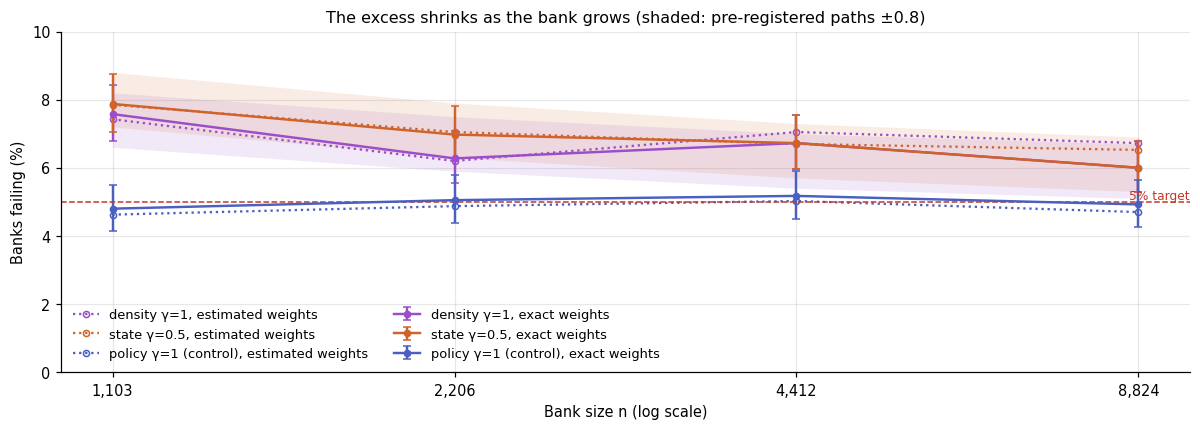

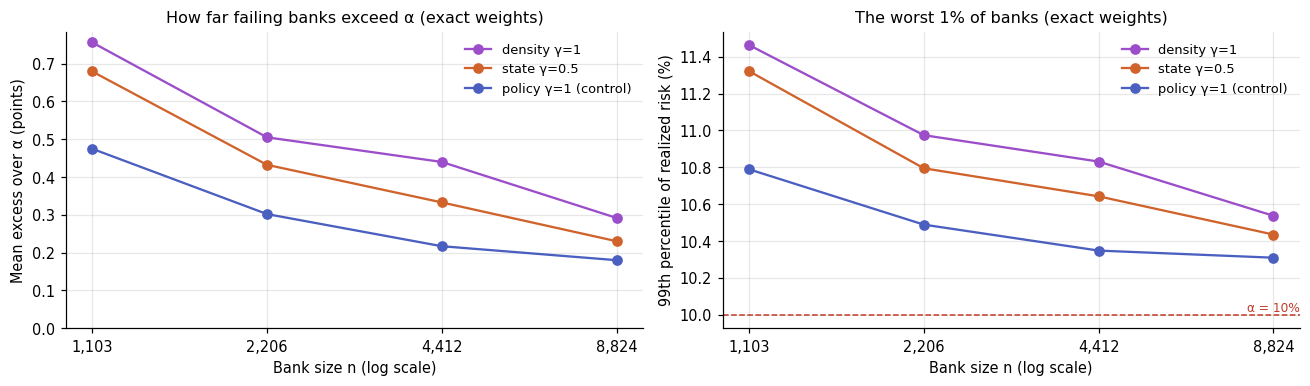

**Bank-size sweep (iid banks, normalized score, 4,000 trials per row)**

,Tilt,n,WBCP exact w,WBCP est. w,Mean risk,q95,q99,Mean excess | fail (points),Calibration n_eff
0,density γ=1,1103,"7.6% [6.8, 8.4]","7.4% [6.6, 8.3]",7.21%,10.37%,11.46%,0.76,391
1,density γ=1,2206,"6.3% [5.5, 7.1]","6.2% [5.5, 7.0]",7.95%,10.12%,10.97%,0.50,777
2,density γ=1,4412,"6.7% [6.0, 7.5]","7.1% [6.3, 7.9]",8.53%,10.16%,10.83%,0.44,1547
3,density γ=1,8824,"6.0% [5.3, 6.8]","6.7% [6.0, 7.5]",8.96%,10.05%,10.54%,0.29,3086
4,state γ=0.5,1103,"7.9% [7.1, 8.8]","7.9% [7.0, 8.7]",7.69%,10.33%,11.32%,0.68,529
5,state γ=0.5,2206,"7.0% [6.2, 7.8]","7.1% [6.3, 7.9]",8.31%,10.19%,10.79%,0.43,1053
6,state γ=0.5,4412,"6.7% [6.0, 7.5]","6.7% [5.9, 7.5]",8.78%,10.11%,10.64%,0.33,2092
7,state γ=0.5,8824,"6.0% [5.3, 6.8]","6.5% [5.8, 7.3]",9.14%,10.05%,10.43%,0.23,4174
8,policy γ=1 (control),1103,"4.8% [4.2, 5.5]","4.6% [4.0, 5.3]",8.20%,9.98%,10.79%,0.47,743
9,policy γ=1 (control),2206,"5.1% [4.4, 5.8]","4.9% [4.2, 5.6]",8.70%,10.00%,10.49%,0.30,1486


In [11]:
NS = [1103, 2206, 4412, 8824]
SWEEP = [("density γ=1", W + "a_density1", "density", 1.0, COL["c5"], [7.4, 6.7, 6.2, 5.9]),
         ("state γ=0.5", W + "a_state05", "state", 0.5, COL["c6"], [8.0, 7.1, 6.5, 6.1]),
         ("policy γ=1 (control)", W + "a_policy1", "policy", 1.0, COL["c3"], None)]
fig, ax = plt.subplots(figsize=(11, 4))
for name, e, t, y, color, path in SWEEP:
    if path:
        ax.fill_between(NS, [v - 0.8 for v in path], [v + 0.8 for v in path], color=color, alpha=0.12, lw=0)
    line(ax, NS, [A(e, t, y, n, "WBCP (oracle w)") for n in NS], f"{name}, exact weights", color)
    ax.plot(NS, [pct(A(e, t, y, n, "WBCP")) for n in NS], ls=":", marker="o", mfc="none", ms=4, color=color, label=f"{name}, estimated weights")
target(ax); ax.set_xscale("log"); ax.set_xticks(NS, [f"{n:,}" for n in NS]); ax.minorticks_off(); ax.set_ylim(0, 10)
ax.set_xlabel("Bank size n (log scale)"); ax.set_ylabel("Banks failing (%)")
ax.set_title("The excess shrinks as the bank grows (shaded: pre-registered paths ±0.8)"); ax.legend(ncol=2, loc="lower left")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for name, e, t, y, color, _ in SWEEP:
    arms = [A(e, t, y, n, "WBCP (oracle w)") for n in NS]
    axes[0].plot(NS, [100 * a["x"] for a in arms], marker="o", color=color, label=name)
    axes[1].plot(NS, [100 * a["q99"] for a in arms], marker="o", color=color, label=name)
for ax in axes:
    ax.set_xscale("log"); ax.set_xticks(NS, [f"{n:,}" for n in NS]); ax.minorticks_off(); ax.set_xlabel("Bank size n (log scale)"); ax.legend()
axes[0].set_ylim(0, None); axes[0].set_ylabel("Mean excess over α (points)"); axes[0].set_title("How far failing banks exceed α (exact weights)")
target(axes[1], 10, "α = 10%"); axes[1].set_ylabel("99th percentile of realized risk (%)"); axes[1].set_title("The worst 1% of banks (exact weights)")
plt.tight_layout(); plt.show()

rows = [[name, n, fail(a), fail(A(e, t, y, n, "WBCP")), f"{100 * a['r']:.2f}%", f"{100 * a['q95']:.2f}%", f"{100 * a['q99']:.2f}%", f"{100 * a['x']:.2f}", round(B(e, t, y, n)["ne"])]
        for name, e, t, y, _, _ in SWEEP for n in NS for a in [A(e, t, y, n, "WBCP (oracle w)")]]
display(Markdown("**Bank-size sweep (iid banks, normalized score, 4,000 trials per row)**"))
display(table(rows, ["Tilt", "n", "WBCP exact w", "WBCP est. w", "Mean risk", "q95", "q99", "Mean excess | fail (points)", "Calibration n_eff"]))

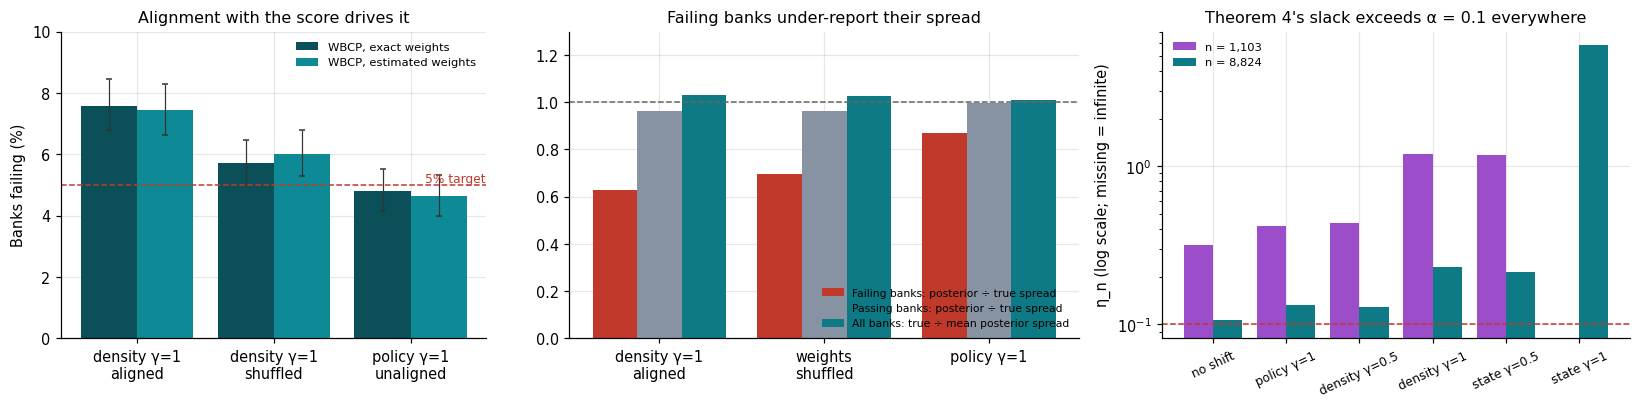

**Per-bank mechanism (exact weights, 4,000 banks × 4,000 posterior draws)**

,Case,Failure (%),From posterior at λ* (%),Agreement,True ÷ mean posterior SD,Failing: posterior ÷ true SD,Passing: posterior ÷ true SD,"corr(R̂, SD)",Skewness of R̂
0,density γ=1 aligned,7.58,7.52,0.9925,1.033,0.629,0.964,0.814,0.395
1,density γ=1 shuffled,5.70,5.83,0.9948,1.025,0.698,0.963,0.801,0.314
2,policy γ=1,4.80,4.78,0.9952,1.009,0.869,0.996,0.927,0.162


**Theorem 4 slack for the benchmark's weights (δ = 0.05, m = ⌈√n⌉)**

,Tilt,γ,n,B = max w ÷ mean w,E[w²],n_eff (population),η_n Hoeffding,η_n Bernstein
0,policy,0.0,1103,1.00,1.000,1103,0.159,0.319
1,policy,0.0,8824,1.00,1.000,8824,0.057,0.107
2,policy,1.0,1103,3.06,1.484,743,0.487,0.419
3,policy,1.0,8824,3.06,1.484,5944,0.16,0.132
4,density,0.5,1103,6.54,1.288,856,1.342,0.438
5,density,0.5,8824,6.54,1.288,6850,0.358,0.129
6,density,1.0,1103,33.23,2.865,385,∞,1.185
7,density,1.0,8824,33.23,2.865,3080,5.975,0.231
8,state,0.5,1103,38.63,2.121,520,∞,1.174
9,state,0.5,8824,38.63,2.121,4160,13.418,0.214


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), gridspec_kw={"width_ratios": [1, 1.2, 1.1]})
src = [(W + "a_density1", "density", 1.0), (W + "b_shuffled_density1", "density", 1.0), (W + "a_policy1", "policy", 1.0)]
grouped(axes[0], ["density γ=1\naligned", "density γ=1\nshuffled", "policy γ=1\nunaligned"], [(ARMS[k], [A(e, t, y, 1103, k) for e, t, y in src], COL[k], None) for k in ("WBCP (oracle w)", "WBCP")], ylim=(0, 10))
target(axes[0]); axes[0].set_title("Alignment with the score drives it"); axes[0].legend(loc="upper right", fontsize=7.5)
cases = [("aligned", "density γ=1\naligned"), ("shuffled", "weights\nshuffled"), ("policy", "policy γ=1")]
metrics = [("failing_median_posterior_sd_over_across", "Failing banks: posterior ÷ true spread", COL["target"]),
           ("passing_median_posterior_sd_over_across", "Passing banks: posterior ÷ true spread", COL["pred"]),
           ("sd_ratio_across_over_posterior", "All banks: true ÷ mean posterior spread", COL["accent"])]
x = np.arange(3)
for i, (key, name, color) in enumerate(metrics):
    axes[1].bar(x - 0.27 + 0.27 * i, [D["mech"][c][key] for c, _ in cases], 0.27, color=color, label=name)
axes[1].axhline(1, color="#666", ls="--", lw=1); axes[1].set_xticks(x, [c[1] for c in cases]); axes[1].set_ylim(0, 1.3)
axes[1].set_title("Failing banks under-report their spread"); axes[1].legend(fontsize=7, loc="lower right")
tcases = [("policy", 0.0, "no shift"), ("policy", 1.0, "policy γ=1"), ("density", 0.5, "density γ=0.5"), ("density", 1.0, "density γ=1"), ("state", 0.5, "state γ=0.5"), ("state", 1.0, "state γ=1")]
x = np.arange(len(tcases))
for i, n in enumerate((1103, 8824)):
    vals = [next((r["eta_bernstein"] for r in D["slack"] if r["tilt"] == t and r["gamma"] == y and r["n"] == n), None) for t, y, _ in tcases]
    axes[2].bar(x - 0.2 + 0.4 * i, [np.nan if v is None else v for v in vals], 0.4, color=COL["c5"] if i == 0 else COL["accent"], label=f"n = {n:,}")
axes[2].axhline(0.1, color=COL["target"], ls="--", lw=1); axes[2].set_yscale("log"); axes[2].set_xticks(x, [c[2] for c in tcases], rotation=25, fontsize=8)
axes[2].set_ylabel("η_n (log scale; missing = infinite)"); axes[2].set_title("Theorem 4's slack exceeds α = 0.1 everywhere"); axes[2].legend(fontsize=7.5)
plt.tight_layout(); plt.show()

rows = [[c, round(D["mech"][k]["fail"] * 100, 2), round(D["mech"][k]["fail_from_posterior_at_lambda_star"] * 100, 2), round(D["mech"][k]["agreement"], 4), round(D["mech"][k]["sd_ratio_across_over_posterior"], 3),
         round(D["mech"][k]["failing_median_posterior_sd_over_across"], 3), round(D["mech"][k]["passing_median_posterior_sd_over_across"], 3), round(D["mech"][k]["corr_r_hat_posterior_sd"], 3), round(D["mech"][k]["r_hat_skewness"], 3)]
        for k, c in (("aligned", "density γ=1 aligned"), ("shuffled", "density γ=1 shuffled"), ("policy", "policy γ=1"))]
display(Markdown("**Per-bank mechanism (exact weights, 4,000 banks × 4,000 posterior draws)**"))
display(table(rows, ["Case", "Failure (%)", "From posterior at λ* (%)", "Agreement", "True ÷ mean posterior SD", "Failing: posterior ÷ true SD", "Passing: posterior ÷ true SD", "corr(R̂, SD)", "Skewness of R̂"]))
rows = [[r["tilt"], r["gamma"], r["n"], round(r["B"], 2), round(r["E_w2"], 3), round(r["n_eff_pop"]), "∞" if r["eta_hoeffding"] is None else round(r["eta_hoeffding"], 3), "∞" if r["eta_bernstein"] is None else round(r["eta_bernstein"], 3)] for r in D["slack"]]
display(Markdown("**Theorem 4 slack for the benchmark's weights (δ = 0.05, m = ⌈√n⌉)**"))
display(table(rows, ["Tilt", "γ", "n", "B = max w ÷ mean w", "E[w²]", "n_eff (population)", "η_n Hoeffding", "η_n Bernstein"]))

**What the paper says** (Lou and Luo, *Weighted Bayesian Conformal Prediction*, arXiv:2604.06464v3):

> Credibility no longer coincides with confidence. (§1)

> WBCP certifies every trial at 7.5–7.9%. The oracle row attributes the residual to η_n, not weight estimation.
> (§4.2; Table 2 at n = 250: 7.9% with estimated weights, 5.6% with oracle weights)

## 9. Reproducing the paper's Tables 1 and 2

Lou and Luo (arXiv:2604.06464v3) validate WBCP on two synthetic benchmarks. Reproducing them checks our
implementation against the authors' own numbers before it is trusted on D4RL.

- **Table 1 (§4.1), regression.** X ~ U[0, 4], Y | X ~ N(0, X²), score |Y|, miscoverage loss, α = 0.1,
  n = 200, test covariates tilted by exp(x). `experiments/wbcp/reproduce_table1.py`.
- **Table 2 (§4.2), multilabel count loss.** x ~ N(0, 1). Each unit has K = 4 outcomes T_k | x ~ Exp(rate(x)),
  and its loss is the share of its outcomes above λ (so a larger λ is safer). α = 0.4, test covariates N(1, 1),
  reported at n = 10 and n = 250. `experiments/wbcp/reproduce_table2.py`.
- **Both.** β = 0.95, 10,000 trials, weights from a logistic classifier fit on samples disjoint from the
  calibration set. A trial *fails* when the true risk of its deployed threshold under the test law exceeds α.
  Rates are over the trials that certified, with exact 95% intervals.

**What had to be inferred.**
- **rate(x).** The paper does not give it. We assume rate(x) = exp(b − a x) and fit a and b to the shift-blind
  rows only. BQ-CP and RCPS see no test data, so their thresholds depend on the calibration law alone.
  - The ratios of their mean thresholds (n = 10 over n = 250) point to a ≈ 0.69-0.70.
  - Their n = 10 failure rates point to a ≈ 0.67.
  - We use a = ln 2, which follows the ratios; b = −0.019 then fits the four mean thresholds.
  - The blind rows are therefore fits, not tests. Every W-CRC and WBCP number in Table 2 is a prediction.
- **RCPS rounding.** The paper's RCPS numbers match the Hoeffding-Bentkus bound only when its binomial term uses
  ⌊nR̂⌋. The published bound (Bates et al., 2021) uses ⌈nR̂⌉. The two agree for Table 1's miscoverage loss and
  differ for the count loss, so both are shown. A likely cause: `scipy.stats.binom.cdf` floors a non-integer
  count without warning.
- **Unstated settings.** Classifier and test-mass sample sizes (200 each) and posterior draws (1,000).
- **Test-atom mass.** WBCP's oracle row is shown with the Eq. (6) mass E_test[w*] and with mass 1.
- **W-CRC's test point** enters with the plug-in mass w̄ (the paper's §3.1). Appendix C's literal CRC Prop. 2 form,
  with the test point's own weight, fails about 33% at n = 10 and does not match the paper's row.

Expectations were written before the W-CRC and WBCP rows were run (`runs/wbcp_paper/expectations.md`, SHA-256
`9b63f675…5dad`). A dated addendum written after the runs corrects its description of the fit; it changes no
expectation (with the addendum: `5204b8f7…ecc2`).

In [13]:
import hashlib
import json

from experiments.wbcp import reproduce_table1 as T1, reproduce_table2 as T2

PP = ROOT / "runs" / "wbcp_paper"
P = {f.stem: json.loads(f.read_text()) for f in sorted(PP.glob("*.json"))}
print(f"{len(P)} reproduction runs: {', '.join(P)}")
print(f"expectations.md SHA-256 {hashlib.sha256((PP / 'expectations.md').read_bytes()).hexdigest()}")
SHORT = {"BQ-CP": "BQ-CP", "RCPS": "RCPS", "RCPS (floor)": "RCPS ⌊nR̂⌋", "W-CRC": "W-CRC", "WBCP": "WBCP",
         "WBCP (oracle w)": "WBCP oracle", "WBCP (oracle, wbar=1)": "oracle, mass 1"}


def pf(row, key="fail"):
    return "–" if row is None or row.get(key) is None else f"{100 * row[key]:.1f}%"


def pci(row):
    return "–" if row is None or row.get("fail") is None else f"{100 * row['fail']:.1f}% [{100 * row['ci'][0]:.1f}, {100 * row['ci'][1]:.1f}]"


t1 = P["t1_g1"]["summary"]
rows = [[name, pci(t1[name]), f"{100 * paper[0]:.1f}%", pf(t1[name], "risk"), f"{100 * paper[1]:.1f}%", f"{t1[name]['length']:.2f}", f"{paper[2]:.2f}"]
        for name, paper in T1.PAPER.items()]
display(Markdown(f"**Table 1, γ = 1 (n = 200, α = 0.1): ours against the paper.** λ* = {P['t1_g1']['lambda_star']:.3f}; "
                 "the paper prints one oracle row, compared with both test-atom masses."))
display(table(rows, ["Rule", "Fail [95% CI]", "Paper fail", "Mean risk", "Paper risk", "Mean length", "Paper length"]))
t0 = P["t1_g0"]["summary"]
display(Markdown(f"Exchangeable control (γ = 0): BQ-CP fails {pci(t0['BQ-CP'])} and WBCP {pci(t0['WBCP'])}; the paper reports 2.6%."))

for n in (10, 250):
    run = P[f"t2_g1_n{n}"]
    rows = [[name, pci(r), f"{100 * freq:.1f}%", "–" if r["mean_lambda"] is None else f"{r['mean_lambda']:.2f}", f"{lam:.2f}",
             f"{100 * r['abstain']:.1f}%", "0 per caption; its CI implies ≈96%" if name not in T2.PAPER_ABSTAIN[n] else f"{100 * T2.PAPER_ABSTAIN[n][name]:.0f}%"]
            for name, (freq, lam) in T2.PAPER[n].items() for r in [run["summary"][name]]]
    display(Markdown(f"**Table 2, γ = 1, n = {n} (α = 0.4): ours against the paper.** λ* = {run['lambda_star']:.3f} under the test law "
                     f"({run['lambda_star_cal']:.3f} under the calibration law); mean n_eff of the estimated weights {run['mean_n_eff']:.1f}."))
    display(table(rows, ["Rule", "Fail [95% CI]", "Paper fail", "Mean λ", "Paper mean λ", "Abstain", "Paper abstain"]))

17 reproduction runs: sens_a065_n10, sens_a065_n250, sens_a075_n10, sens_a075_n250, sens_fit1000_n10, sens_fit1000_n250, t1_g0, t1_g1, t2_g0_n10, t2_g0_n100, t2_g0_n250, t2_g1_n10, t2_g1_n100, t2_g1_n250, t2_g2_n10, t2_g2_n100, t2_g2_n250
expectations.md SHA-256 5204b8f722ad0ed3725d7b9c07910d935d657b90463b039bab42b2a49498ecc2


**Table 1, γ = 1 (n = 200, α = 0.1): ours against the paper.** λ* = 5.300; the paper prints one oracle row, compared with both test-atom masses.

,Rule,Fail [95% CI],Paper fail,Mean risk,Paper risk,Mean length,Paper length
0,BQ-CP,"92.8% [92.2, 93.3]",92.3%,14.6%,14.4%,9.30,9.35
1,RCPS,"85.7% [85.0, 86.3]",85.2%,13.5%,13.3%,9.62,9.67
2,W-CRC,"41.2% [40.2, 42.2]",42.8%,9.6%,9.5%,10.95,10.98
3,WBCP,"5.1% [4.7, 5.5]",5.0%,4.9%,5.0%,13.44,13.41
4,WBCP (oracle w),"4.9% [4.5, 5.4]",6.7%,4.9%,5.4%,13.42,13.09
5,"WBCP (oracle, wbar=1)","7.0% [6.5, 7.5]",6.7%,5.4%,5.4%,13.06,13.09


Exchangeable control (γ = 0): BQ-CP fails 3.8% [3.4, 4.2] and WBCP 5.7% [5.3, 6.2]; the paper reports 2.6%.

**Table 2, γ = 1, n = 10 (α = 0.4): ours against the paper.** λ* = 1.866 under the test law (0.933 under the calibration law); mean n_eff of the estimated weights 5.6.

,Rule,Fail [95% CI],Paper fail,Mean λ,Paper mean λ,Abstain,Paper abstain
0,BQ-CP,"29.4% [28.5, 30.3]",28.2%,2.42,2.44,0.0%,0%
1,RCPS,"2.4% [2.1, 2.7]",5.7%,4.22,3.49,0.0%,0%
2,RCPS (floor),"6.2% [5.7, 6.7]",5.7%,3.48,3.49,0.0%,0%
3,W-CRC,"11.8% [11.2, 12.5]",13.2%,3.49,3.31,3.3%,4%
4,WBCP,"0.0% [0.0, 0.4]",0.0%,11.21,7.61,91.8%,93%
5,WBCP (oracle w),"0.0% [0.0, 0.5]",0.0%,12.64,7.94,93.3%,0 per caption; its CI implies ≈96%
6,"WBCP (oracle, wbar=1)","1.4% [1.1, 1.6]",0.0%,4.68,7.94,9.2%,0 per caption; its CI implies ≈96%


**Table 2, γ = 1, n = 250 (α = 0.4): ours against the paper.** λ* = 1.866 under the test law (0.933 under the calibration law); mean n_eff of the estimated weights 98.2.

,Rule,Fail [95% CI],Paper fail,Mean λ,Paper mean λ,Abstain,Paper abstain
0,BQ-CP,"100.0% [100.0, 100.0]",100.0%,1.05,1.05,0.0%,0%
1,RCPS,"100.0% [100.0, 100.0]",100.0%,1.17,1.16,0.0%,0%
2,RCPS (floor),"100.0% [100.0, 100.0]",100.0%,1.16,1.16,0.0%,0%
3,W-CRC,"46.3% [45.3, 47.2]",43.7%,1.94,1.92,0.0%,0%
4,WBCP,"10.2% [9.6, 10.8]",7.9%,2.42,2.36,0.0%,0%
5,WBCP (oracle w),"7.0% [6.6, 7.6]",5.6%,2.37,2.35,0.0%,0%
6,"WBCP (oracle, wbar=1)","9.2% [8.7, 9.8]",5.6%,2.33,2.35,0.0%,0%


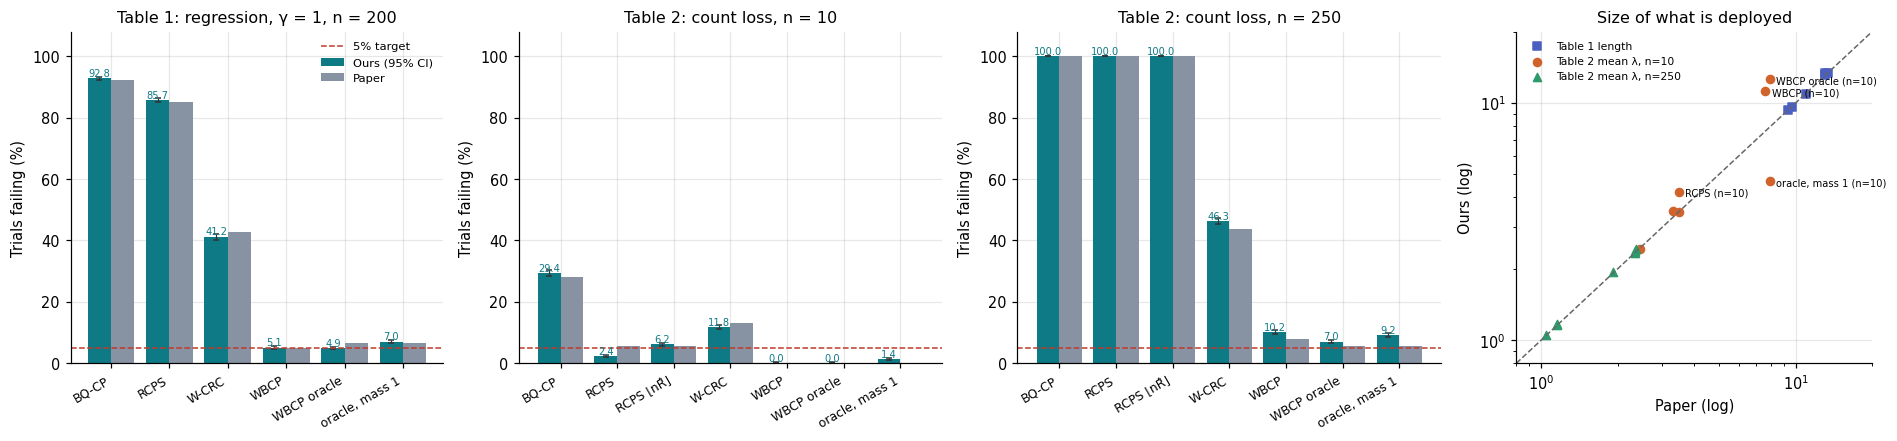

In [14]:
def versus(ax, summary, paper, title):
    names = list(paper)
    x = np.arange(len(names))
    rows = [summary[k] for k in names]
    ours = np.array([np.nan if r.get("fail") is None else 100 * r["fail"] for r in rows])
    err = [[o - 100 * r["ci"][0] if np.isfinite(o) else 0 for o, r in zip(ours, rows)],
           [100 * r["ci"][1] - o if np.isfinite(o) else 0 for o, r in zip(ours, rows)]]
    ax.bar(x - 0.2, ours, 0.4, yerr=err, color=COL["accent"], label="Ours (95% CI)", error_kw=dict(elinewidth=0.8, capsize=1.8, ecolor="#333"))
    ax.bar(x + 0.2, [100 * paper[k][0] for k in names], 0.4, color=COL["pred"], label="Paper")
    for xi, o, p in zip(x, ours, [100 * paper[k][0] for k in names]):
        ax.annotate(f"{o:.1f}", (xi - 0.2, o), ha="center", va="bottom", fontsize=6.5, color=COL["accent"])
    ax.set_xticks(x, [SHORT[k] for k in names], rotation=30, ha="right", fontsize=8)
    ax.axhline(5, color=COL["target"], ls="--", lw=1, label="5% target")
    ax.set_ylabel("Trials failing (%)"); ax.set_ylim(0, 108); ax.set_title(title)


fig, axes = plt.subplots(1, 4, figsize=(17.5, 4.1), gridspec_kw={"width_ratios": [1.1, 1.25, 1.25, 1.05]})
versus(axes[0], P["t1_g1"]["summary"], T1.PAPER, "Table 1: regression, γ = 1, n = 200")
versus(axes[1], P["t2_g1_n10"]["summary"], {k: v for k, v in T2.PAPER[10].items()}, "Table 2: count loss, n = 10")
versus(axes[2], P["t2_g1_n250"]["summary"], {k: v for k, v in T2.PAPER[250].items()}, "Table 2: count loss, n = 250")
axes[0].legend(loc="upper right", fontsize=7.5)
ax = axes[3]
points = [("T1", k, P["t1_g1"]["summary"][k]["length"], T1.PAPER[k][2]) for k in T1.PAPER]
points += [(f"n={n}", k, P[f"t2_g1_n{n}"]["summary"][k]["mean_lambda"], T2.PAPER[n][k][1]) for n in (10, 250) for k in T2.PAPER[n]]
for tag, color, marker in (("T1", COL["c3"], "s"), ("n=10", COL["c6"], "o"), ("n=250", COL["c4"], "^")):
    sel = [(o, p) for t, _, o, p in points if t == tag and o is not None]
    ax.scatter([p for _, p in sel], [o for o, _ in sel], color=color, marker=marker, s=28, label="Table 1 length" if tag == "T1" else f"Table 2 mean λ, {tag}")
lim = (0.8, 20)
ax.plot(lim, lim, color="#666", ls="--", lw=1); ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(*lim); ax.set_ylim(*lim)
for t, k, o, p in points:
    if o is not None and abs(math.log(o / p)) > 0.15:
        ax.annotate(f"{SHORT[k]} ({t})", (p, o), fontsize=6.5, xytext=(4, -3), textcoords="offset points")
ax.set_xlabel("Paper (log)"); ax.set_ylabel("Ours (log)"); ax.set_title("Size of what is deployed"); ax.legend(fontsize=7, loc="upper left")
plt.tight_layout(); plt.show()

**Appendix C's sweep.** The paper also runs Table 2's benchmark at γ ∈ {0, 1, 2} and n from 10 to 250, and describes
three regimes:
- **γ = 0** (no shift, where WBCP is BQ-CP): WBCP fails 0.3-2.2% with no abstention; W-CRC fails 24-33%.
- **γ = 1**: the blind rules fail in essentially every trial by n = 100; WBCP certifies every trial at 7.5-7.9%.
- **γ = 2**: BQ-CP fails 91-100% (risk up to 0.74); WBCP abstains in every trial up to n = 100 and in 75% at
  n = 250, and never fails when it certifies.

We ran n ∈ {10, 100, 250} at each γ. RCPS is the published (⌈nR̂⌉) bound.

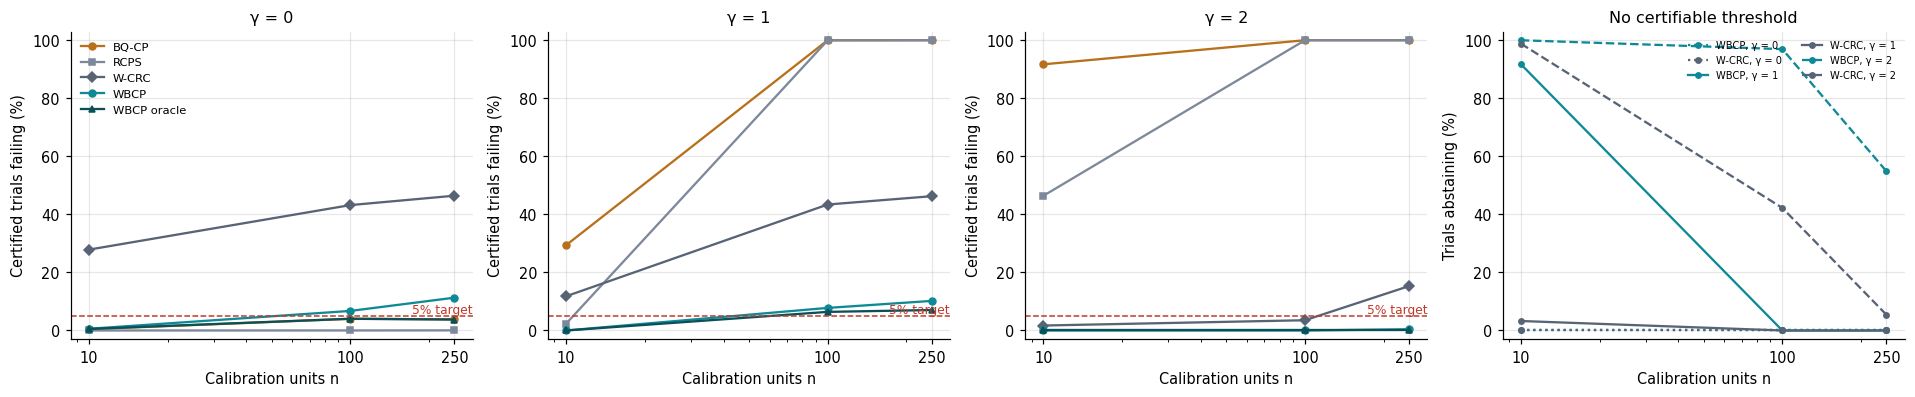

**Appendix C sweep (estimated weights unless marked oracle; 10,000 trials per row)**

,γ,n,λ*,n_eff,BQ-CP,RCPS,W-CRC,WBCP,WBCP oracle,WBCP abstain,W-CRC abstain,BQ-CP mean risk
0,0,10,0.933,9.9,"0.4% [0.3, 0.6]","0.0% [0.0, 0.0]","27.9% [27.0, 28.7]","0.6% [0.4, 0.7]","0.5% [0.4, 0.7]",0.0%,0.0%,17.0%
1,0,100,0.933,99.0,"4.0% [3.6, 4.4]","0.0% [0.0, 0.1]","43.2% [42.2, 44.2]","6.7% [6.3, 7.2]","4.0% [3.7, 4.5]",0.0%,0.0%,34.4%
2,0,250,0.933,247.4,"3.9% [3.5, 4.3]","0.0% [0.0, 0.1]","46.4% [45.4, 47.4]","11.3% [10.7, 11.9]","3.8% [3.4, 4.1]",0.0%,0.0%,36.6%
3,1,10,1.866,5.6,"29.4% [28.5, 30.3]","2.4% [2.1, 2.7]","11.8% [11.2, 12.5]","0.0% [0.0, 0.4]","0.0% [0.0, 0.5]",91.8%,3.3%,34.5%
4,1,100,1.866,41.6,"100.0% [100.0, 100.0]","100.0% [99.9, 100.0]","43.4% [42.4, 44.4]","7.8% [7.3, 8.3]","6.4% [5.9, 6.9]",0.0%,0.0%,55.1%
5,1,250,1.866,98.2,"100.0% [100.0, 100.0]","100.0% [100.0, 100.0]","46.3% [45.3, 47.2]","10.2% [9.6, 10.8]","7.0% [6.6, 7.6]",0.0%,0.0%,57.2%
6,2,10,3.732,3.1,"91.7% [91.1, 92.2]","46.4% [45.4, 47.4]","1.7% [0.2, 6.0]","0.0% [0.0, 97.5]","0.0% [0.0, 97.5]",100.0%,98.8%,54.4%
7,2,100,3.732,11.4,"100.0% [100.0, 100.0]","100.0% [100.0, 100.0]","3.5% [3.1, 4.0]","0.0% [0.0, 1.2]","0.0% [0.0, 7.7]",96.9%,42.2%,72.6%
8,2,250,3.732,20.6,"100.0% [100.0, 100.0]","100.0% [100.0, 100.0]","15.3% [14.6, 16.0]","0.4% [0.3, 0.7]","0.0% [0.0, 0.1]",54.9%,5.4%,74.1%


In [15]:
NS2 = (10, 100, 250)
SW = [("BQ-CP", COL["BQ-CP"], "o"), ("RCPS", COL["RCPS"], "s"), ("W-CRC", COL["W-CRC"], "D"), ("WBCP", COL["WBCP"], "o"), ("WBCP (oracle w)", COL["WBCP (oracle w)"], "^")]


def cell(g, n, name):
    run = P.get(f"t2_g{g}_n{n}")
    return None if run is None else run["summary"][name]


fig, axes = plt.subplots(1, 4, figsize=(17.5, 3.7))
for ax, g in zip(axes, (0, 1, 2)):
    for name, color, marker in SW:
        rows = [cell(g, n, name) for n in NS2]
        y = [np.nan if r is None or r.get("fail") is None else 100 * r["fail"] for r in rows]
        ax.plot(NS2, y, marker=marker, color=color, ms=4.5, lw=1.5, label=SHORT[name])
    target(ax); ax.set_xscale("log"); ax.set_xticks(NS2, [str(n) for n in NS2]); ax.set_ylim(-3, 103)
    ax.set_xlabel("Calibration units n"); ax.set_ylabel("Certified trials failing (%)"); ax.set_title(f"γ = {g}")
axes[0].legend(fontsize=7.5, loc="upper left")
ax = axes[3]
for g, ls in ((0, ":"), (1, "-"), (2, "--")):
    for name, color in (("WBCP", COL["WBCP"]), ("W-CRC", COL["W-CRC"])):
        rows = [cell(g, n, name) for n in NS2]
        ax.plot(NS2, [np.nan if r is None else 100 * r["abstain"] for r in rows], color=color, ls=ls, marker="o", ms=3.5, label=f"{name}, γ = {g}")
ax.set_xscale("log"); ax.set_xticks(NS2, [str(n) for n in NS2]); ax.set_ylim(-3, 103)
ax.set_xlabel("Calibration units n"); ax.set_ylabel("Trials abstaining (%)"); ax.set_title("No certifiable threshold"); ax.legend(fontsize=6.5, ncol=2)
plt.tight_layout(); plt.show()

rows = []
for g in (0, 1, 2):
    for n in NS2:
        run = P.get(f"t2_g{g}_n{n}")
        if run is None:
            continue
        s = run["summary"]
        rows.append([g, n, round(run["lambda_star"], 3), round(run["mean_n_eff"], 1)] + [pci(s[k]) for k, _, _ in SW]
                    + [pf(s["WBCP"], "abstain"), pf(s["W-CRC"], "abstain"), pf(s["BQ-CP"], "risk")])
display(Markdown("**Appendix C sweep (estimated weights unless marked oracle; 10,000 trials per row)**"))
display(table(rows, ["γ", "n", "λ*", "n_eff", *[SHORT[k] for k, _, _ in SW], "WBCP abstain", "W-CRC abstain", "BQ-CP mean risk"]))

In [16]:
SENS = [("Default: a = ln 2, b = −0.019, samples 200", "t2_g1_n{}"), ("Classifier and test-mass samples 1,000", "sens_fit1000_n{}"),
        ("Slope a = 0.65 (b = −0.040)", "sens_a065_n{}"), ("Slope a = 0.75 (b = +0.011)", "sens_a075_n{}")]
rows = []
for label, pattern in SENS:
    for n in (10, 250):
        run = P.get(pattern.format(n))
        if run is None:
            continue
        s = run["summary"]
        rows.append([label, n, round(run["lambda_star"], 3)] + [pci(s[k]) for k in ("BQ-CP", "RCPS (floor)", "W-CRC", "WBCP", "WBCP (oracle w)")]
                    + [pf(s["WBCP"], "abstain"), "–" if s["WBCP"]["mean_lambda"] is None else round(s["WBCP"]["mean_lambda"], 2)])
display(Markdown("**Sensitivity to what the paper leaves unstated (γ = 1).** Paper at n = 10: BQ-CP 28.2%, RCPS 5.7%, W-CRC 13.2%, "
                 "WBCP 0.0% (abstains 93%). At n = 250: 100%, 100%, 43.7%, 7.9% (oracle 5.6%)."))
display(table(rows, ["Setting", "n", "λ*", "BQ-CP", "RCPS ⌊nR̂⌋", "W-CRC", "WBCP", "WBCP oracle", "WBCP abstain", "WBCP mean λ"]))

**Sensitivity to what the paper leaves unstated (γ = 1).** Paper at n = 10: BQ-CP 28.2%, RCPS 5.7%, W-CRC 13.2%, WBCP 0.0% (abstains 93%). At n = 250: 100%, 100%, 43.7%, 7.9% (oracle 5.6%).

,Setting,n,λ*,BQ-CP,RCPS ⌊nR̂⌋,W-CRC,WBCP,WBCP oracle,WBCP abstain,WBCP mean λ
0,"Default: a = ln 2, b = −0.019, samples 200",10,1.866,"29.4% [28.5, 30.3]","6.2% [5.7, 6.7]","11.8% [11.2, 12.5]","0.0% [0.0, 0.4]","0.0% [0.0, 0.5]",91.8%,11.21
1,"Default: a = ln 2, b = −0.019, samples 200",250,1.866,"100.0% [100.0, 100.0]","100.0% [100.0, 100.0]","46.3% [45.3, 47.2]","10.2% [9.6, 10.8]","7.0% [6.6, 7.6]",0.0%,2.42
2,"Classifier and test-mass samples 1,000",10,1.866,"28.9% [28.0, 29.8]","5.8% [5.4, 6.3]","9.9% [9.3, 10.5]","0.0% [0.0, 0.5]","0.0% [0.0, 0.6]",93.2%,12.21
3,"Classifier and test-mass samples 1,000",250,1.866,"100.0% [100.0, 100.0]","100.0% [100.0, 100.0]","46.9% [45.9, 47.8]","7.6% [7.1, 8.2]","6.5% [6.1, 7.0]",0.0%,2.36
4,Slope a = 0.65 (b = −0.040),10,1.823,"26.6% [25.7, 27.4]","5.0% [4.6, 5.4]","11.1% [10.5, 11.7]","0.0% [0.0, 0.4]","0.0% [0.0, 0.5]",91.8%,10.39
5,Slope a = 0.65 (b = −0.040),250,1.823,"100.0% [100.0, 100.0]","100.0% [100.0, 100.0]","46.5% [45.5, 47.5]","10.0% [9.4, 10.6]","7.2% [6.7, 7.7]",0.0%,2.33
6,Slope a = 0.75 (b = +0.011),10,1.921,"32.7% [31.8, 33.6]","7.8% [7.3, 8.4]","12.4% [11.8, 13.1]","0.0% [0.0, 0.4]","0.0% [0.0, 0.5]",91.8%,12.38
7,Slope a = 0.75 (b = +0.011),250,1.921,"100.0% [100.0, 100.0]","100.0% [100.0, 100.0]","46.7% [45.7, 47.7]","10.5% [10.0, 11.2]","7.2% [6.7, 7.7]",0.0%,2.54


**Scorecard against the pre-registered expectations** (`runs/wbcp_paper/expectations.md`)

| # | Expectation | Result | Met? |
|---|---|---|---|
| 1 | n = 250: blind rules fail 100% | 100% each | Yes (fitted, not a test) |
| 2 | n = 250: W-CRC fails 35-50%, mean λ 1.85-2.00 | 46.3% [45.3, 47.2], 1.94 (paper 43.7% [42.8, 44.7], 1.92) | Yes, though outside the paper's interval |
| 3 | n = 250: WBCP fails 5-10%, mean λ 2.25-2.45 | 10.2% [9.6, 10.8], 2.42 (paper 7.9% [7.4, 8.5], 2.36) | No, just above |
| 4 | n = 250: oracle WBCP (Eq. 6 mass) fails 4-8% | 7.0% [6.6, 7.6], 2.37 (paper 5.6% [5.1, 6.0], 2.35) | Yes, though outside the paper's interval |
| 5 | Oracle with mass 1 fails more than item 4 | 9.2% | Yes |
| 6 | n = 10: WBCP abstains 85-97%, fails 0-2% when it certifies, mean λ above 5 | Abstains 91.8%, fails 0.0%, mean λ 11.21 (paper 93%, 0.0%, 7.61) | Yes |
| 7 | n = 10: oracle (Eq. 6) abstains 90-98% (paper about 96% from its interval); mass 1 abstains 30-60%; the paper's oracle row is the Eq. 6 mass | 93.3%; mass 1 abstains 9.2% and fails 1.4%. The paper's row rules out mass 1 but implies more abstention than Eq. 6 gives | Partly |
| 8 | n = 10: W-CRC abstains 2-7%, fails 10-17%, mean λ 3.0-3.6 | 3.3%, 11.8%, 3.49 (paper 4%, 13.2%, 3.31) | Yes |
| 9 | n = 10: RCPS ⌈⌉ about 2-3% / 4.4; ⌊⌋ about 6-7% / 3.5 | 2.4% / 4.22; 6.2% / 3.48 (paper 5.7% / 3.49) | Yes (fitted, not a test; ⌈⌉ mean 4.22 against about 4.4) |
| 10 | n = 100: blind rules fail at least 95%; WBCP certifies all trials and fails 5-10% | BQ-CP 100%, RCPS 99.95%; WBCP abstains 0.0% and fails 7.8% (paper 7.5-7.9%) | Yes (the blind part follows from the fit) |
| 11 | γ = 0: WBCP fails 0.3-3%; W-CRC fails 20-35% | WBCP 0.6 / 6.7 / 11.3% at n = 10 / 100 / 250; W-CRC 27.9 / 43.2 / 46.4% | No |
| 12 | γ = 2: BQ-CP fails 90-100% (risk 0.70-0.76 at n = 250); WBCP abstains nearly always to n = 100, 50-90% at n = 250, never fails when certifying | 91.7-100%, risk 0.741; abstains 100 / 96.9 / 54.9%; fails 0.0% at n = 100 and 0.4% at n = 250 | Mostly: 0.4% is not "never" |
| 13 | Classifier and test-mass samples of 1,000 move WBCP toward the oracle by under 2 points | 10.2% → 7.6% (oracle 6.5%), 2.6 points | No: right direction, larger move |
| 14 | Slope 0.65 or 0.75 moves WBCP (n = 250) under 3 points | 10.0% and 10.5% | Yes |
| 15 | Table 1 rerun reproduces the README table | Identical at printed precision (all six rows: failure, interval, risk, length) | Yes |

**Why the misses happened.**
- **Item 3: WBCP at n = 250 runs 2.3 points above the paper (10.2% against 7.9%). Two parts, only one explained.**
  - About 1.4 points also appear in the exact-weight row: 7.0% against 5.6%, and 6.5-7.2% at every slope and
    sample size tried. That part is not weight estimation, and its cause is not identified.
  - The rest is the estimated-weight premium: estimated minus oracle is 3.2 points here and 2.3 in the paper.
    It shrinks with a larger classifier sample (item 13).
- **Item 11: estimated weights add error even with no shift.**
  - At γ = 0 the classifier's slope is pure noise, but the score depends strongly on x, so the noise tilts the
    weighted risk curve. As n grows the posterior concentrates on the tilted curve: 0.6% → 6.7% → 11.3%.
  - With exactly uniform weights (the oracle row at γ = 0) failure stays at 0.5 / 4.0 / 3.8%.
  - This is Theorem 4's weight-error × non-pivotal-score term. It is the same mechanism found on walker2d in
    Change 10, where a 10× larger classifier sample largely removed it (14.9% → 5.7%).
  - Table 1 shows it as well: at γ = 0, estimated-weight WBCP fails 5.7% against 3.7% with exact weights.
  - The paper's γ = 0 statement is about WBCP = BQ-CP with equal weights, so the estimated-weight rows do not
    contradict it. The paper does not mention this cost.
- **Item 11, equal weights and W-CRC.**
  - Even with equal weights, BQ-CP fails 4.0% and 3.9% at n = 100 and 250, above the paper's 0.3-2.2%.
  - W-CRC's 43-46% is what an expectation-only rule gives at large n.
  - The cause of the gap is not identified. Candidates are design details the paper does not state, such as
    the form of rate(x) beyond the fitted slope.
- **Item 13.** The unstated sample sizes matter more than pre-registered.
  - They move WBCP by 2.6 points, enough to bring it inside the paper's interval (7.6% [7.1, 8.2]).
  - They do not bring W-CRC (n = 10: 9.9% against 13.2%) or the oracle row (6.5% against 5.6%) closer. So this
    does not show that the paper used a larger classifier.
- **Item 7.** At n = 10, abstention depends only on the weights and the test mass, not on rate(x). It is
  identical at slopes 0.65 and 0.75. The paper's oracle interval [0.0, 0.9] implies about 410 certified trials,
  i.e. about 96% abstention. Eq. (6) gives 93.3%; matching 96% would take a test mass near 3.0 rather than
  e = 2.72. With mass 1 most trials certify.

**Not predicted.**
- **Mean λ at n = 10.** Only "above 5" was pre-registered. Over the about 8% of trials that certify, WBCP's mean λ
  is 11.2 (oracle 12.6) against the paper's 7.61 (7.94). This conditional mean is driven by the upper tail of T,
  which the fit to mid-range thresholds does not pin down: the deployed λ is usually the largest or second-largest
  of the 40 outcomes.
- **Abstention at n = 10.** Failure rates match (0.0%). Abstention, which tests the weights and test mass directly,
  is close but not equal:
  - Estimated-weight WBCP abstains 91.8% against the paper's 93% (93.2% with 1,000-sample weights).
  - The Eq. (6) oracle abstains 93.3% against about 96%.
- **Table 1's exchangeable control.** BQ-CP fails 3.8% at γ = 0, against the paper's 2.6% (documented earlier: the
  exact infinite-draw value is 3.20%).

**Verdict.**
- **Table 1.** The shift rows reproduce to within about 2 points (W-CRC 41.2% against 42.8% is the largest gap).
  Two caveats: the oracle row matches test mass 1 rather than Eq. (6), and the exchangeable control (3.8% against
  2.6%) does not reproduce.
- **Table 2 at n = 10.** WBCP abstains instead of failing: 91.8% abstention and no failures, against the paper's
  93% and none. W-CRC (11.8%, abstaining 3.3%) is close to the paper's 13.2% and 4%. The blind rows were used to
  fit rate(x), so they are not a test.
- **Table 2 at n = 250.** At the pre-registered settings it does not reproduce quantitatively. WBCP fails 10.2%
  [9.6, 10.8] against 7.9% [7.4, 8.5], and W-CRC and the oracle row also fall outside the paper's intervals. The
  qualitative result holds: WBCP certifies every trial at a few points above the 5% target, while the blind rules
  fail every trial.
- **RCPS.** The paper's numbers need a non-published rounding.

For BCA, the lesson that carries over is the one in Change 10: split-estimated weights need a large fitting sample
when the score is not pivotal, or WBCP fails more often than its 5% target even with no shift.

## 10. All results

Every result block from every run: one row per experiment, tilt, bank size and score, with each rule's failure
rate and 95% interval. The last columns (mean risk, percentiles, excess, threshold, abstention) are for WBCP with
estimated weights. Percentiles and excess exist only for runs from Change 10 on.

In [17]:
rows = []
for b in D["blocks"]:
    e, d = EXP[b["e"]], b["A"].get("WBCP", {})
    rows.append([e["change"], b["e"], e["dataset"], e["design"], b["n"], "none" if b["y"] == 0 else b["t"], b["y"], b["s"], round(b["L"], 3), round(b["ne"]),
                 fail(b["A"].get("BQ-CP")), fail(b["A"].get("WBCP")), fail(b["A"].get("WBCP (oracle w)")), fail(b["A"].get("RCPS")), fail(b["A"].get("W-CRC")),
                 None if d.get("r") is None else round(100 * d["r"], 2), None if d.get("q95") is None else round(100 * d["q95"], 2),
                 None if d.get("q99") is None else round(100 * d["q99"], 2), None if d.get("x") is None else round(100 * d["x"], 2),
                 None if d.get("th") is None else round(d["th"], 3), None if d.get("ab") is None else round(100 * d["ab"], 1)])
ALL = table(rows, ["Change", "Experiment", "Dataset", "Bank design", "n", "Tilt", "γ", "Score", "λ*", "n_eff", "Uniform BCA", "WBCP est. w", "WBCP exact w",
                   "RCPS", "W-CRC", "WBCP mean risk (%)", "WBCP q95 (%)", "WBCP q99 (%)", "WBCP excess | fail", "WBCP threshold", "WBCP abstain (%)"])
print(f"{len(ALL)} result blocks")
ALL

258 result blocks


,Change,Experiment,Dataset,Bank design,n,Tilt,γ,Score,λ*,n_eff,Uniform BCA,WBCP est. w,WBCP exact w,RCPS,W-CRC,WBCP mean risk (%),WBCP q95 (%),WBCP q99 (%),WBCP excess | fail,WBCP threshold,WBCP abstain (%)
0,1,wbcp_bench/blocks,hopper-medium,Whole episodes,1103,none,0.0,normalized,1.064,1362,"28.0% [26.0, 30.0]","28.1% [26.1, 30.1]","28.2% [26.2, 30.2]","21.6% [19.8, 23.5]","53.3% [51.0, 55.5]",8.84,NaN,NaN,NaN,1.135,0.0
1,1,wbcp_bench/blocks,hopper-medium,Whole episodes,1103,none,0.0,raw,2.198,1362,"31.8% [29.7, 33.8]","31.7% [29.7, 33.8]","31.9% [29.8, 33.9]","25.8% [23.9, 27.8]","54.2% [52.0, 56.4]",8.92,NaN,NaN,NaN,2.358,0.0
2,1,wbcp_bench/blocks,hopper-medium,Whole episodes,1103,policy,0.5,normalized,1.062,1174,"27.6% [25.6, 29.6]","24.7% [22.8, 26.7]","24.7% [22.8, 26.7]","21.1% [19.3, 23.0]","52.0% [49.8, 54.2]",8.71,NaN,NaN,NaN,1.139,0.0
3,1,wbcp_bench/blocks,hopper-medium,Whole episodes,1103,policy,0.5,raw,2.204,1174,"32.5% [30.4, 34.6]","28.2% [26.2, 30.2]","28.8% [26.8, 30.8]","26.7% [24.8, 28.7]","53.3% [51.0, 55.5]",8.79,NaN,NaN,NaN,2.380,0.0
4,1,wbcp_bench/blocks,hopper-medium,Whole episodes,1103,policy,1.0,normalized,1.066,917,"28.6% [26.6, 30.6]","21.5% [19.7, 23.4]","21.4% [19.6, 23.3]","22.6% [20.8, 24.5]","51.6% [49.3, 53.8]",8.52,NaN,NaN,NaN,1.156,0.0
5,1,wbcp_bench/blocks,hopper-medium,Whole episodes,1103,policy,1.0,raw,2.218,917,"34.5% [32.4, 36.6]","24.8% [22.9, 26.8]","24.6% [22.7, 26.5]","28.7% [26.7, 30.7]","52.6% [50.4, 54.8]",8.57,NaN,NaN,NaN,2.427,0.0
6,1,wbcp_bench/blocks,hopper-medium,Whole episodes,1103,none,0.0,normalized,1.064,1362,"28.0% [26.0, 30.0]","28.2% [26.2, 30.2]","28.1% [26.1, 30.1]","21.6% [19.8, 23.5]","53.9% [51.7, 56.1]",8.84,NaN,NaN,NaN,1.134,0.0
7,1,wbcp_bench/blocks,hopper-medium,Whole episodes,1103,none,0.0,raw,2.198,1362,"31.8% [29.7, 33.8]","32.0% [29.9, 34.0]","31.6% [29.5, 33.6]","25.8% [23.9, 27.8]","54.5% [52.2, 56.6]",8.92,NaN,NaN,NaN,2.358,0.0
8,1,wbcp_bench/blocks,hopper-medium,Whole episodes,1103,density,0.5,normalized,1.129,1068,"53.8% [51.5, 56.0]","32.0% [29.9, 34.0]","31.9% [29.9, 34.0]","46.9% [44.6, 49.1]","57.4% [55.2, 59.6]",8.78,NaN,NaN,NaN,1.217,0.0
9,1,wbcp_bench/blocks,hopper-medium,Whole episodes,1103,density,0.5,raw,2.377,1068,"57.7% [55.4, 59.8]","34.9% [32.8, 37.0]","34.9% [32.8, 37.0]","52.3% [50.0, 54.5]","57.1% [54.8, 59.2]",8.86,NaN,NaN,NaN,2.576,0.0


## 11. Provenance

Expectations were written to timestamped files before each run. They are not under version control, so their
SHA-256 values are listed to be sent to the advisor or committed. The full write-up, with every verdict and its
reasoning, is `experiments/wbcp/DEPENDENCE.md`.

In [18]:
display(table([[x["change"], x["label"], x["header"], x["file"], x["sha"]] for x in D["expectations"]], ["Change", "Expectations", "Header", "File", "SHA-256"]))
display(table([[e["change"], e["label"], e["file"], e["dataset"], e["design"], e["trials"], e["seed"]] for e in D["exps"]], ["Change", "Experiment", "File", "Dataset", "Bank design", "Trials", "Seed"]))

,Change,Expectations,Header,File,SHA-256
0,2-4,Design-effect predictions,created 2026-09-30T14:42:52.242845+00:00,wbcp_dependence/hopper-u100000/predictions.json,dad16f4afb075c6e1be285f8d463665ff581a3918449bdeea53c1d10...
1,5,Shift re-check under thinned banks,Pre-registered expectation for the shift re-check (2026-...,wbcp_dependence/hopper-u100000/expectations_shift.md,9e93ea06bdf3c321c6e659e409c9375fe79f129e4edba68089834fb8...
2,6-7,Spaced banks under shift,Pre-registered expectation for spaced banks under shift ...,wbcp_dependence/hopper-u100000-spacing/expectations_shif...,4b2c302d5ef778a58e9666f8402766b355547bc3aebcfa8fc52f9cd1...
3,8,Spaced K = 5 under shift,Pre-registered expectation: stratified K = 5 under shift...,wbcp_dependence/hopper-u100000-spacing/expectations_stra...,43138765f28740364b3e434c451b4fd8243bfcf8b308f211b514bfba...
4,9,BCA's thinned reservation,Pre-registered expectations: stratified reservation in B...,wbcp_dependence/hopper-u100000-reservation/expectations.md,566034c5238635459b2c23d2a5030f0cfaa2c78e6ffb3951c0c5a758...
5,10,"Two more datasets (stages A, B, D)",Pre-registered expectations: dependence on walker2d-medi...,wbcp_dependence/other-datasets/expectations.md,add84dee25f679e7ad36cf6122241d3dae00f8fc4656a2dadb29fd4f...
6,11,Why WBCP exceeds 5% under strong shift,Pre-registered expectations: why WBCP exceeds 5% under s...,wbcp_dependence/hopper-u100000-weighting/expectations.md,ee65c8458807ef4c580fc1f3e2ed188a58faabc631c2f077f9cd9c98...


,Change,Experiment,File,Dataset,Bank design,Trials,Seed
0,1,"Whole-episode banks, every tilt",wbcp_bench/blocks.json,hopper-medium,Whole episodes,2000,2026093001
1,5,"Shift baseline, independent rows",wbcp_bench/main.json,hopper-medium,Independent rows,2000,2026093001
2,5,Misspecified weight model,wbcp_bench/rawdisc.json,hopper-medium,"Independent rows, misspecified weights",2000,2026093001
3,4,"Independent rows, no shift",wbcp_dependence/hopper-u100000/e0_iid.json,hopper-medium,Independent rows,4000,2026093001
4,3,Whole-episode banks by size,wbcp_dependence/hopper-u100000/e1_blocks.json,hopper-medium,Whole episodes,4000,2026093001
5,4,Random K rows per episode,wbcp_dependence/hopper-u100000/e2_k1.json,hopper-medium,K=1 random,4000,2026093001
6,4,Random K rows per episode,wbcp_dependence/hopper-u100000/e2_k2.json,hopper-medium,K=2 random,4000,2026093001
7,4,Random K rows per episode,wbcp_dependence/hopper-u100000/e2_k5.json,hopper-medium,K=5 random,4000,2026093001
8,4,Random K rows per episode,wbcp_dependence/hopper-u100000/e2_k10.json,hopper-medium,K=10 random,4000,2026093001
9,4,Random K rows per episode,wbcp_dependence/hopper-u100000/e2_k25.json,hopper-medium,K=25 random,4000,2026093001
